In [1]:
# Cell 1: Setting Environment
"""
# CIC-IoT-2023 Transformer Training Pipeline
## Phase 2 - Model Implementation Focus
"""

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras        #Advanced API (Simplified Model Building)
from tensorflow.keras import layers        #Neural network layers (Dense, LSTM, Transformer, etc.)
import glob     #Batch file reading (e.g., 169 CSV files)
import os       #Operating system interface (path handling)
from tqdm import tqdm       #Progress bar display
from sklearn.preprocessing import LabelEncoder, StandardScaler      #Text labels → Numbers/Data normalization (mean = 0, standard deviation = 1)
from sklearn.model_selection import train_test_split        #Dataset splitting (train/test)
import warnings
warnings.filterwarnings('ignore')       #Suppress warning messages (make output cleaner)

print(f"TensorFlow Version: {tf.__version__}")      #Confirm TensorFlow version
print(f"GPUs Available: {len(tf.config.list_physical_devices('GPU'))}")     #Confirm the number of GPU
for gpu in tf.config.list_physical_devices('GPU'):      #List all GPUs
    print(f"  {gpu}")

2025-11-30 18:35:50.482440: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow Version: 2.20.0
GPUs Available: 4
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
  PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')
  PhysicalDevice(name='/physical_device:GPU:2', device_type='GPU')
  PhysicalDevice(name='/physical_device:GPU:3', device_type='GPU')


In [2]:
# # Cell 1.5: Install SMOTE library
# !pip install imbalanced-learn
# from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
# from imblearn.combine import SMOTETomek
# from collections import Counter
# print("✅ imbalanced-learn installed")

In [3]:
# Cell 2: Configuration
"""
### Configuration (Paper's Optimal Settings)
"""

class Config:       #Centralize configuration of all parameters
    # Paths
    DATA_DIR = "./data/merged"      #Path of the merged dataset
    MODELS_DIR = "./models"     #Models save path

    # Data parameters
    TEST_SIZE = 0.2     #Test set accounts for 20%
    RANDOM_STATE = 42       #Random Seed, Fix randomness to ensure reproducibility

    # Model parameters (from paper Table 26)
    INPUT_DIM = 39   # Dataset features *In paper, it has 46 features
    EMBED_DIM = 512  # Embedding dimension，Best: 512 （According to the Paper)
    NUM_HEADS = 1    # Number of attention heads， Best: 1 head （According to the Paper)
    FF_DIM = 512     # Feed-forward dimension (512 is the best according to the paper(FF_DIM))
    DROPOUT = 0.1    # Paper's dropout (Randomly drop 10% of neurons during training to prevent overfitting）

    # Training parameters
    """
    Total samples: 37,349,263
    Number of batches (per epoch): 37,349,263/1024 =36473
    In each epoch, our model processes roughly 36,473 batches, each containing 1,024 samples
    """
    BATCH_SIZE = 1024  # Paper's batch size
    EPOCHS = 15      # Paper's epochs
    LEARNING_RATE = 0.001 #Paper's Standard initial learning rate

    # Model parameters
    NUM_CLASSES = 8

    # Loss function parameters
    USE_FOCAL_LOSS = True
    FOCAL_ALPHA = 0.25
    FOCAL_GAMMA = 2.0

    USE_CLASS_WEIGHTS = True

    # SMOTE parameters
    USE_SMOTE = False #
    SMOTE_STRATEGY = 'auto'  #
    SMOTE_K_NEIGHBORS = 5  #
    SMOTE_METHOD = 'borderline'  # 'basic', 'borderline', 'adasyn'

# Create directories
os.makedirs(Config.MODELS_DIR, exist_ok=True)
print("Configuration loaded ✅")
print(f"  - SMOTE: {Config.USE_SMOTE}")
print(f"  - Focal Loss γ: {Config.FOCAL_GAMMA}")
print(f"  - Epochs: {Config.EPOCHS}")

Configuration loaded ✅
  - SMOTE: False
  - Focal Loss γ: 2.0
  - Epochs: 15


In [4]:
# Cell 2.5: Focal Loss Implementation (FIXED)
"""
### Focal Loss for Class Imbalance
Supports sparse labels (integers) like sparse_categorical_crossentropy
"""

import tensorflow.keras.backend as K

class FocalLoss(tf.keras.losses.Loss):
    """
    Focal Loss for multi-class classification with SPARSE labels
    Compatible with sparse_categorical_crossentropy format
    """
    def __init__(self, alpha=0.25, gamma=2.0, num_classes=8, name='focal_loss'):
        super().__init__(name=name)
        self.alpha = alpha
        self.gamma = gamma
        self.num_classes = num_classes

    def call(self, y_true, y_pred):
        # Convert sparse labels to one-hot encoding
        # y_true shape: [batch_size] → [batch_size, num_classes]
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=self.num_classes)

        # Clip predictions to prevent log(0)
        y_pred = K.clip(y_pred, K.epsilon(), 1 - K.epsilon())

        # Calculate cross entropy
        cross_entropy = -y_true * K.log(y_pred)

        # Calculate focal loss
        focal_loss = self.alpha * K.pow(1 - y_pred, self.gamma) * cross_entropy

        return K.mean(K.sum(focal_loss, axis=-1))

print("✅ Focal Loss class defined (supports sparse labels)")

✅ Focal Loss class defined (supports sparse labels)


In [5]:
# Cell 3:
"""
### Load and Merge All CSV Files
"""

def load_all_data():
    """Load all CSV files and merge them"""
    """
    os.path.join: It can safely join multiple path components into a single complete path according to the operating system’s path rules.
    glob.glob: Find all files matching a pattern (supports *)
    """
    csv_files = sorted(glob.glob(os.path.join(Config.DATA_DIR, "Merged*.csv")))

    print(f"Found {len(csv_files)} CSV files")

    """
    tqdm(): Display a loop progress bar. desc="Loading files" is the descriptive text displayed in front of the progress bar.
    pd.read_csv(): read CSV files as DataFrame
    all_dfs.append(df): put read DataFrame into the list （It will automatically number the items）
    os.path.basename()： Remove the path part and keep only the file name
    len(df)： Get the number of lines.  :, means Format with a thousands separator (like 1,000,000).
    """
    all_dfs = []
    for file in tqdm(csv_files, desc="Loading files"):
        df = pd.read_csv(file)
        all_dfs.append(df)
        print(f"  {os.path.basename(file)}: {len(df):,} rows")

    """
    pd.concat: merged multiple DataFrames. ignore_index+True means reindex. It can avoid duplicate.
    """
    print("\nMerging all dataframes...")
    merged_df = pd.concat(all_dfs, ignore_index=True)

    """
    shape: result will be like(5019243, 40), it is 5019243 lines and 40 columns(1 index included)
    df.columns: Return all column names
    """
    print(f"✅ Total data shape: {merged_df.shape}")
    print(f"   Columns: {list(merged_df.columns)}")

    # Show label distribution (Count the number of occurrences of each value. Show which kind of attack are more common)
    """
    df['label']: Choose 'label' column
    .value_counts: Count the number of occurrences of each value (automatically sorted in descending order).
    .items()：This will convert the Series into a form where both the index and the values can be accessed simultaneously.
                (without item(), it is only a series, and the system will return error)
    """
    print(f"\nLabel distribution (top 10):")
    for label, count in merged_df['Label'].value_counts().head(10).items():
        print(f"  {label}: {count:,}")

    return merged_df

# Load data
df = load_all_data()

Found 63 CSV files


Loading files:   2%|▏         | 1/63 [00:01<01:12,  1.16s/it]

  Merged01.csv: 712,311 rows


Loading files:   3%|▎         | 2/63 [00:02<01:06,  1.08s/it]

  Merged02.csv: 748,585 rows


...

Loading files:  98%|█████████▊| 62/63 [00:59<00:00,  1.13it/s]

  Merged62.csv: 701,507 rows


Loading files: 100%|██████████| 63/63 [01:00<00:00,  1.04it/s]

  Merged63.csv: 428,161 rows

Merging all dataframes...


✅ Total data shape: (45019243, 40)
   Columns: ['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance', 'Label']

Label distribution (top 10):
  DDOS-ICMP_FLOOD: 6,893,259
  DDOS-UDP_FLOOD: 5,181,027
  DDOS-TCP_FLOOD: 4,306,086
  DDOS-PSHACK_FLOOD: 3,920,372
  DDOS-SYN_FLOOD: 3,886,130
  DDOS-RSTFINFLOOD: 3,872,808
  DDOS-SYNONYMOUSIP_FLOOD: 3,445,659
  DOS-UDP_FLOOD: 3,177,323
  DOS-TCP_FLOOD: 2,558,256
  DOS-SYN_FLOOD: 1,942,176


In [6]:
# # Cell 3.5: SMOTE Implementation
# """
# ### SMOTE for Handling Class Imbalance
# """
#
# def apply_smote_to_training_data(X_train, y_train, method='borderline'):
#     """
#     Apply SMOTE to training data
#     """
#     print("="*60)
#     print(f"Applying SMOTE (method: {method})")
#     print("="*60)
#
#     # 1. show original distribution
#     original_distribution = Counter(y_train)
#     print("\n📊 Original class distribution:")
#     for class_id in sorted(original_distribution.keys()):
#         count = original_distribution[class_id]
#         print(f"  Class {class_id}: {count:,}")
#
#     # 2. calculate imbalance ratio
#     max_count = max(original_distribution.values())
#     min_count = min(original_distribution.values())
#     print(f"\n⚠️ Imbalance ratio: {max_count/min_count:.1f}:1")
#
#     # 3. choose SMOTE
#     if method == 'borderline':
#         sampler = BorderlineSMOTE(
#             k_neighbors=Config.SMOTE_K_NEIGHBORS,
#             random_state=Config.RANDOM_STATE
#         )
#     elif method == 'adasyn':
#         sampler = ADASYN(
#             n_neighbors=Config.SMOTE_K_NEIGHBORS,
#             random_state=Config.RANDOM_STATE
#         )
#     else:  # basic
#         sampler = SMOTE(
#             k_neighbors=Config.SMOTE_K_NEIGHBORS,
#             random_state=Config.RANDOM_STATE
#         )
#
#     # 4. applying SMOTE
#     print(f"\n🔄 Applying {method} SMOTE...")
#     X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
#
#     # 5. Show new distribution
#     new_distribution = Counter(y_resampled)
#     print("\n📊 New class distribution after SMOTE:")
#     for class_id in sorted(new_distribution.keys()):
#         old_count = original_distribution[class_id]
#         new_count = new_distribution[class_id]
#         added = new_count - old_count
#         print(f"  Class {class_id}: {new_count:,} (+{added:,} synthetic samples)")
#
#     print(f"\n✅ Total samples: {len(y_train):,} → {len(y_resampled):,}")
#     print(f"✅ Increased by {len(y_resampled) - len(y_train):,} synthetic samples")
#
#     return X_resampled, y_resampled
#
# print("✅ SMOTE functions defined")

In [7]:
# Cell 4: Data Preprocessing (Strategy B: Hierarchical Stage 1 - FIXED)
"""
### Data Preprocessing: Merging DDoS/DoS into 'Flood' (Robust Version)
"""

def preprocess_data(df):
    print("\n" + "="*50)
    print("Data Preprocessing (Strategy B: Hierarchical)")
    print("="*50)

    # 1. Clean data
    print("1. Cleaning data...")
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()

    # 2. Clip extreme values
    print("2. Clipping extreme values...")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    numeric_cols = [col for col in numeric_cols if col != 'Label']
    for col in numeric_cols:
        q_low = df[col].quantile(0.001)
        q_high = df[col].quantile(0.999)
        df[col] = df[col].clip(q_low, q_high)

    # 3. Merge Labels (Robust Logic)
    # ============================================================
    print("3. Merging Labels for Stage 1 (Robust)...")

    def robust_merge(label):
        # Force uppercase to handle case-sensitivity issues
        label = str(label).upper()

        # Strategy B: Group DDoS and DoS directly into 'Flood'
        if 'DDOS' in label or 'DOS' in label:
            return 'Flood'
        elif 'MIRAI' in label:
            return 'Mirai'
        elif 'RECON' in label or 'SCAN' in label or 'DISCOVERY' in label or 'PING' in label:
            return 'Recon'
        elif 'SPOOF' in label or 'MITM' in label:
            return 'Spoofing'
        elif any(x in label for x in ['WEB', 'XSS', 'SQL', 'UPLOADING', 'BROWSER', 'COMMAND']):
            return 'Web-Based'
        elif 'BRUTE' in label:
            return 'BruteForce'
        elif 'BENIGN' in label:
            return 'Benign'
        elif 'MALWARE' in label or 'BACKDOOR' in label:
            return 'Mirai' # Group malware backdoors with Mirai/Botnet
        else:
            return 'Other'

    # Apply the robust mapping
    df['Label'] = df['Label'].apply(robust_merge)

    # Print new class distribution (Should only see 7 or 8 classes now)
    print(f"   New Class Distribution:")
    print(df['Label'].value_counts())
    # ============================================================

    # 4. Encode Labels
    print("4. Encoding labels...")
    # Clean up columns
    if 'Label_Original' in df.columns:
        df = df.drop('Label_Original', axis=1)

    X = df.drop(['Label'], axis=1).values
    le = LabelEncoder()
    y = le.fit_transform(df['Label'].values)
    num_classes = len(le.classes_)
    print(f"   Classes found: {le.classes_}")

    # 5. Split
    print("5. Splitting data...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=Config.TEST_SIZE,
        random_state=Config.RANDOM_STATE, stratify=y
    )

    # 6. Downsampling (Targeting the new 'Flood' class)
    # ============================================================
    print("\n6. Downsampling 'Flood' class...")
    TARGET_MAX_SAMPLES = 2000000

    flood_class_name = 'Flood'

    if flood_class_name in le.classes_:
        flood_id = le.transform([flood_class_name])[0]

        keep_indices = []
        # Iterate through unique classes in y_train
        for class_id in np.unique(y_train):
            # Find indices for this class
            indices = np.where(y_train == class_id)[0]
            count = len(indices)
            class_name = le.inverse_transform([class_id])[0]

            if class_name == flood_class_name and count > TARGET_MAX_SAMPLES:
                print(f"   - {class_name} (Class {class_id}): {count:,} -> {TARGET_MAX_SAMPLES:,} (Downsampling)")
                np.random.seed(Config.RANDOM_STATE)
                selected = np.random.choice(indices, TARGET_MAX_SAMPLES, replace=False)
                keep_indices.extend(selected)
            else:
                print(f"   - {class_name} (Class {class_id}): {count:,} (Kept All)")
                keep_indices.extend(indices)

        # Apply filter
        keep_indices = np.array(keep_indices)
        np.random.shuffle(keep_indices)
        X_train = X_train[keep_indices]
        y_train = y_train[keep_indices]
    else:
        print("   Warning: 'Flood' class not found in encoded labels!")
    # ============================================================

    # 7. Scale
    print("7. Scaling features...")
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Clip to stabilize training
    X_train = np.clip(X_train, -5, 5)
    X_test = np.clip(X_test, -5, 5)

    print(f"\n Preprocessing complete. Final Train Size: {len(X_train):,}")

    return X_train, X_test, y_train, y_test, num_classes, le, None

# Execute
X_train, X_test, y_train, y_test, num_classes, label_encoder, _ = preprocess_data(df)
Config.NUM_CLASSES = num_classes


Data Preprocessing (Strategy B: Hierarchical)
1. Cleaning data...
2. Clipping extreme values...
3. Merging Labels for Stage 1 (Robust)...
   New Class Distribution:
Label
Flood         40282037
Mirai          2524629
Benign         1051313
Recon           661108
Spoofing        465914
Web-Based        20720
BruteForce       12522
Name: count, dtype: int64
4. Encoding labels...
   Classes found: ['Benign' 'BruteForce' 'Flood' 'Mirai' 'Recon' 'Spoofing' 'Web-Based']
5. Splitting data...

6. Downsampling 'Flood' class...
   - Benign (Class 0): 841,050 (Kept All)
   - BruteForce (Class 1): 10,018 (Kept All)
   - Flood (Class 2): 32,225,629 -> 2,000,000 (Downsampling)
   - Mirai (Class 3): 2,019,703 (Kept All)
   - Recon (Class 4): 528,887 (Kept All)
   - Spoofing (Class 5): 372,731 (Kept All)
   - Web-Based (Class 6): 16,576 (Kept All)
7. Scaling features...

 Preprocessing complete. Final Train Size: 5,788,965


In [8]:
# # Cell 4.5: Visualize SMOTE Effect (新增)
# """
# ### Visualize Class Distribution Before/After SMOTE
# """
#
# import matplotlib.pyplot as plt
# import pandas as pd
# from collections import Counter
#
# # 只有在启用SMOTE的情况下才运行可视化
# if Config.USE_SMOTE:
#     # 创建可视化
#     fig, axes = plt.subplots(1, 3, figsize=(18, 6))
#
#     # 1. 原始分布（条形图）
#     # 需要从preprocess_data函数中保存original_y_train
#     # 注意：你需要修改preprocess_data函数，返回original_y_train
#     original_counts = Counter(y_train_original)  # 需要从preprocess_data返回这个
#     classes = sorted(original_counts.keys())
#     class_names = [label_encoder.inverse_transform([c])[0] for c in classes]
#     original_values = [original_counts[c] for c in classes]
#
#     axes[0].bar(range(len(classes)), original_values, color='skyblue')
#     axes[0].set_xlabel('Class')
#     axes[0].set_ylabel('Number of Samples')
#     axes[0].set_title(f'Before SMOTE\n(Total: {len(y_train_original):,})')
#     axes[0].set_xticks(range(len(classes)))
#     axes[0].set_xticklabels(class_names, rotation=45, ha='right')
#
#     # 在条形上添加具体数字
#     for i, v in enumerate(original_values):
#         axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
#
#     # 2. SMOTE后的分布（条形图）
#     smote_counts = Counter(y_train)
#     smote_values = [smote_counts[c] for c in classes]
#
#     axes[1].bar(range(len(classes)), smote_values, color='lightgreen')
#     axes[1].set_xlabel('Class')
#     axes[1].set_ylabel('Number of Samples')
#     axes[1].set_title(f'After SMOTE\n(Total: {len(y_train):,})')
#     axes[1].set_xticks(range(len(classes)))
#     axes[1].set_xticklabels(class_names, rotation=45, ha='right')
#
#     # 在条形上添加具体数字
#     for i, v in enumerate(smote_values):
#         axes[1].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
#
#     # 3. 增加的样本数（条形图）
#     added_samples = [smote_values[i] - original_values[i] for i in range(len(classes))]
#     colors = ['red' if x == 0 else 'green' for x in added_samples]
#
#     axes[2].bar(range(len(classes)), added_samples, color=colors)
#     axes[2].set_xlabel('Class')
#     axes[2].set_ylabel('Synthetic Samples Added')
#     axes[2].set_title('Synthetic Samples Generated')
#     axes[2].set_xticks(range(len(classes)))
#     axes[2].set_xticklabels(class_names, rotation=45, ha='right')
#     axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
#
#     # 在条形上添加具体数字
#     for i, v in enumerate(added_samples):
#         if v > 0:
#             axes[2].text(i, v, f'+{v:,}', ha='center', va='bottom', fontsize=8)
#
#     plt.suptitle('SMOTE Impact on Class Distribution', fontsize=16, fontweight='bold')
#     plt.tight_layout()
#
#     # 保存图片
#     plt.savefig(f'{Config.MODELS_DIR}/smote_distribution_comparison.png', dpi=100, bbox_inches='tight')
#     plt.show()
#
#     # 打印统计信息
#     print("="*60)
#     print("SMOTE STATISTICS SUMMARY")
#     print("="*60)
#     print("\n📊 Class Distribution Changes:")
#     print(f"{'Class':<15} {'Original':<12} {'After SMOTE':<12} {'Added':<12} {'Increase %'}")
#     print("-"*60)
#
#     total_original = sum(original_values)
#     total_smote = sum(smote_values)
#
#     for i, class_name in enumerate(class_names):
#         orig = original_values[i]
#         new = smote_values[i]
#         added = added_samples[i]
#         increase_pct = (added / orig * 100) if orig > 0 else 0
#         print(f"{class_name:<15} {orig:<12,} {new:<12,} {added:<12,} {increase_pct:>10.1f}%")
#
#     print("-"*60)
#     print(f"{'TOTAL':<15} {total_original:<12,} {total_smote:<12,} {total_smote-total_original:<12,} {(total_smote-total_original)/total_original*100:>10.1f}%")
#
#     # 计算不平衡度的改善
#     original_imbalance = max(original_values) / min(original_values)
#     smote_imbalance = max(smote_values) / min(smote_values)
#
#     print(f"\n📈 Imbalance Ratio:")
#     print(f"   Before SMOTE: {original_imbalance:.1f}:1")
#     print(f"   After SMOTE:  {smote_imbalance:.1f}:1")
#     print(f"   Improvement:  {(1 - smote_imbalance/original_imbalance)*100:.1f}%")
#
# else:
#     print("⚠️ SMOTE is disabled. Enable it in Config to see visualization.")

In [9]:
# Cell 5:
"""
### Transformer Model (Paper Architecture)
"""

class TransformerBlock(layers.Layer):
    """Transformer encoder block"""

    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim,
            dropout=dropout
        )
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def call(self, inputs, training=None):  # 修改：training设为可选参数
        attn_output = self.att(inputs, inputs, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1, training=training)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)


def create_transformer_model(input_dim, num_classes):
    """Create the Transformer model"""

    inputs = layers.Input(shape=(input_dim,))

    # Reshape to (batch_size, 1, features)
    x = layers.Reshape((1, input_dim))(inputs)

    # Project to embedding dimension (512)
    x = layers.Dense(Config.EMBED_DIM)(x)

    # Transformer block
    transformer_block = TransformerBlock(
        Config.EMBED_DIM,
        Config.NUM_HEADS,
        Config.FF_DIM,
        Config.DROPOUT
    )
    x = transformer_block(x)  # 简化调用方式

    # Global pooling and output
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(Config.DROPOUT)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    print(f"✅ Transformer model created")
    print(f"   Parameters: {model.count_params():,}")

    return model

# Create model
transformer = create_transformer_model(Config.INPUT_DIM, num_classes)

I0000 00:00:1764545915.901340   52887 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22494 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1764545915.901869   52887 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22403 MB memory:  -> device: 1, name: NVIDIA RTX A5000, pci bus id: 0000:2b:00.0, compute capability: 8.6
I0000 00:00:1764545915.902342   52887 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 21998 MB memory:  -> device: 2, name: NVIDIA RTX A5000, pci bus id: 0000:41:00.0, compute capability: 8.6
I0000 00:00:1764545915.902773   52887 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 22494 MB memory:  -> device: 3, name: NVIDIA RTX A5000, pci bus id: 0000:61:00.0, compute capability: 8.6


✅ Transformer model created
   Parameters: 1,602,055


In [10]:
# Cell 6:
"""
### DNN Baseline Model (for comparison)
"""

def create_dnn_model(input_dim, num_classes):
    """Create DNN baseline (3 layers, 768 neurons as per paper)"""

    model = keras.Sequential([
        # Layer 1
        layers.Dense(256, activation='relu', input_shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dropout(Config.DROPOUT),

        # Layer 2
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(Config.DROPOUT),

        # Layer 3
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(Config.DROPOUT),

        # Output
        layers.Dense(num_classes, activation='softmax')
    ])

    print(f"✅ DNN model created")
    print(f"   Parameters: {model.count_params():,}")

    return model

# Create DNN
dnn = create_dnn_model(Config.INPUT_DIM, num_classes)

✅ DNN model created
   Parameters: 146,695


In [11]:
# Cell 6.1:
"""
### CNN Model (for comparison)
"""

def create_cnn_model(input_dim, num_classes):
    """Create CNN model for tabular data"""

    model = keras.Sequential([
        # Reshape input for Conv1D (batch_size, features, 1)
        layers.Reshape((input_dim, 1), input_shape=(input_dim,)),

        # Conv Block 1
        layers.Conv1D(128, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(Config.DROPOUT),

        # Conv Block 2
        layers.Conv1D(256, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(Config.DROPOUT),

        # Conv Block 3
        layers.Conv1D(512, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        layers.Dropout(Config.DROPOUT),

        # Dense layers
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(Config.DROPOUT),

        # Output
        layers.Dense(num_classes, activation='softmax')
    ])

    print(f"✅ CNN model created")
    print(f"   Parameters: {model.count_params():,}")

    return model

# Create CNN
cnn = create_cnn_model(Config.INPUT_DIM, num_classes)

✅ CNN model created
   Parameters: 630,535


In [12]:
# Cell 6.5: Calculate Class Weights (Strategy B: 7-Class)
"""
### Compute Class Weights for 7-Class Classification (Flood Merged)
"""
from sklearn.utils.class_weight import compute_class_weight

def calculate_class_weights(y_train, num_classes, le):
    # 1. Base balanced weights
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.arange(num_classes),
        y=y_train
    )
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

  
    print(f"\n⚖️  Applying Manual Weight Adjustments (Strategy B):")

    try:

        recon_idx = le.transform(['Recon'])[0]
        bf_idx = le.transform(['BruteForce'])[0]
        flood_idx = le.transform(['Flood'])[0]
        web_idx = le.transform(['Web-Based'])[0]


        class_weight_dict[recon_idx] *= 2.0
        class_weight_dict[bf_idx] *= 2.0
        class_weight_dict[web_idx] *= 1.5


        class_weight_dict[flood_idx] *= 0.8

        print(f"   - Targeted: Recon(x2.0), BruteForce(x2.0), Web(x1.5)")
        print(f"   - Suppressed: Flood(x0.8)")

    except Exception as e:
        print(f"⚠️  Weight adjustment error: {e}")

    print("\n📊 Final Class Weights:")
    for i, w in class_weight_dict.items():
        name = le.inverse_transform([i])[0]
        print(f"  Class {i} ({name:12s}): {w:.4f}")

    return class_weight_dict

# Execute
if Config.USE_CLASS_WEIGHTS:
    class_weight_dict = calculate_class_weights(y_train, Config.NUM_CLASSES, label_encoder)


⚖️  Applying Manual Weight Adjustments (Strategy B):
   - Targeted: Recon(x2.0), BruteForce(x2.0), Web(x1.5)
   - Suppressed: Flood(x0.8)

📊 Final Class Weights:
  Class 0 (Benign      ): 0.9833
  Class 1 (BruteForce  ): 165.1018
  Class 2 (Flood       ): 0.3308
  Class 3 (Mirai       ): 0.4095
  Class 4 (Recon       ): 3.1273
  Class 5 (Spoofing    ): 2.2187
  Class 6 (Web-Based   ): 74.8367


In [14]:
# Cell 6.6: Custom Macro F1 Callback (Optimized)
"""
### Macro F1-Score Callback for Imbalanced Dataset (Optimized Version)
"""

from sklearn.metrics import f1_score

class MacroF1Callback(keras.callbacks.Callback):
    """
    Monitor Macro F1-Score with sampling for large datasets.
    """

    def __init__(self, validation_data, patience=5, min_delta=0.001, max_samples=500000):
        super().__init__()
        self.X_val = validation_data[0]
        self.y_val = validation_data[1]
        self.patience = patience
        self.min_delta = min_delta
        self.max_samples = max_samples  # 最大采样数

        # Tracking variables
        self.best_f1 = 0
        self.wait = 0
        self.best_weights = None
        self.best_epoch = 0
        self.history = []

    def on_epoch_end(self, epoch, logs=None):
        """Called at the end of each epoch"""


        if len(self.y_val) > self.max_samples:
            indices = np.random.choice(len(self.y_val), self.max_samples, replace=False)
            X_sample = self.X_val[indices]
            y_sample = self.y_val[indices]
        else:
            X_sample = self.X_val
            y_sample = self.y_val

        # 1. Generate predictions (with larger batch size for speed)
        y_pred_proba = self.model.predict(X_sample, batch_size=4096, verbose=0)
        y_pred = np.argmax(y_pred_proba, axis=1)

        # 2. Calculate Macro F1-Score
        macro_f1 = f1_score(y_sample, y_pred, average='macro')
        self.history.append(macro_f1)

        # 3. Add to logs
        if logs is not None:
            logs['val_macro_f1'] = macro_f1

        # 4. Check if this is the best model
        if macro_f1 > self.best_f1 + self.min_delta:
            self.best_f1 = macro_f1
            self.wait = 0
            self.best_weights = self.model.get_weights()
            self.best_epoch = epoch + 1
            print(f" - val_macro_f1: {macro_f1:.4f} ⬆️ New best!")
        else:
            self.wait += 1
            print(f" - val_macro_f1: {macro_f1:.4f} (patience: {self.wait}/{self.patience})")

            if self.wait >= self.patience:
                print(f"\n⏹️ Early Stopping! Best Macro F1: {self.best_f1:.4f} at epoch {self.best_epoch}")
                self.model.stop_training = True

    def on_train_end(self, logs=None):
        """Restore best weights"""
        if self.best_weights is not None:
            print(f"\n✅ Restoring best weights from epoch {self.best_epoch} (Macro F1: {self.best_f1:.4f})")
            self.model.set_weights(self.best_weights)

print("✅ MacroF1Callback defined (optimized for large datasets)")

✅ MacroF1Callback defined (optimized for large datasets)


In [15]:
# Cell 7: Training Function (FIXED & OPTIMIZED)
"""
### Training Function (Fixed Batch Size & Sampling)
"""

def train_model(model, model_name, X_train, y_train, X_test, y_test):
    """Train and evaluate a model using Macro F1 as the primary metric"""

    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")

    # 1. Compile model
    if Config.USE_FOCAL_LOSS:
        loss_function = FocalLoss(
            alpha=Config.FOCAL_ALPHA,
            gamma=Config.FOCAL_GAMMA,
            num_classes=Config.NUM_CLASSES
        )
        print(f"📊 Using Focal Loss (α={Config.FOCAL_ALPHA}, γ={Config.FOCAL_GAMMA})")
    else:
        loss_function = 'sparse_categorical_crossentropy'
        print(f"📊 Using Standard CrossEntropy")

    model.compile(
        optimizer=keras.optimizers.Adam(Config.LEARNING_RATE),
        loss=loss_function,
        metrics=['accuracy']
    )

    # 2. Setup Callbacks
    macro_f1_callback = MacroF1Callback(
        validation_data=(X_test, y_test),
        patience=5,
        min_delta=0.001
    )

    callbacks = [
        macro_f1_callback,
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        ),
    ]

    print(f"📊 Early Stopping: Based on val_macro_f1 (patience=5)")
    print(f"📊 LR Reduction: Based on val_loss (patience=2)")

    # 3. Train the model
    history = model.fit(
        X_train, y_train,
        batch_size=Config.BATCH_SIZE,
        epochs=Config.EPOCHS,
        validation_data=(X_test, y_test),
        callbacks=callbacks,
        verbose=1,
        class_weight=class_weight_dict if Config.USE_CLASS_WEIGHTS else None
    )

    # ============================================
    # 4. Final Evaluation (Optimized)
    # ============================================
    print("\n📊 Calculating final metrics (using optimized sampling)...")

    # If test set is too large
    eval_size = 200000
    if len(y_test) > eval_size:
        indices = np.random.choice(len(y_test), eval_size, replace=False)
        X_eval = X_test[indices]
        y_eval = y_test[indices]
    else:
        X_eval = X_test
        y_eval = y_test

    # batch_size
    y_pred = np.argmax(model.predict(X_eval, batch_size=Config.BATCH_SIZE, verbose=0), axis=1)

    final_macro_f1 = f1_score(y_eval, y_pred, average='macro')
    # evaluate batch_size
    test_loss, test_acc = model.evaluate(X_eval, y_eval, batch_size=Config.BATCH_SIZE, verbose=0)

    print(f"\n{'='*60}")
    print(f"✅ {model_name} Final Results (on {len(y_eval):,} samples):")
    print(f"   Test Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"   Test Macro F1:  {final_macro_f1:.4f} ({final_macro_f1*100:.2f}%)")
    print(f"   Best Macro F1:  {macro_f1_callback.best_f1:.4f} (epoch {macro_f1_callback.best_epoch})")
    print(f"{'='*60}")

    history.history['val_macro_f1'] = macro_f1_callback.history

    return history, test_acc, final_macro_f1

In [16]:
# Cell 8:
"""
### Train Transformer Model
"""
print(f"✅ Dataset size: {len(X_train):,} samples")
print(f"✅ Batch size: {Config.BATCH_SIZE}")
print(f"✅ Epochs: {Config.EPOCHS}")


batches_per_epoch = len(X_train) // Config.BATCH_SIZE
print(f"📊 Batches per epoch: {batches_per_epoch:,}")
print(f"⏱️ Estimated time per epoch: {batches_per_epoch * 0.006:.0f} seconds")

transformer_history, transformer_acc, transformer_f1 = train_model(
    transformer, "transformer", X_train, y_train, X_test, y_test
)


✅ Dataset size: 5,788,965 samples
✅ Batch size: 1024
✅ Epochs: 15
📊 Batches per epoch: 5,653
⏱️ Estimated time per epoch: 34 seconds

Training transformer
📊 Using Focal Loss (α=0.25, γ=2.0)
📊 Early Stopping: Based on val_macro_f1 (patience=5)
📊 LR Reduction: Based on val_loss (patience=2)
Epoch 1/15


2025-11-30 18:38:41.798107: I external/local_xla/xla/service/service.cc:163] XLA service 0x70e998003920 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-30 18:38:41.798142: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA RTX A5000, Compute Capability 8.6
2025-11-30 18:38:41.798149: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (1): NVIDIA RTX A5000, Compute Capability 8.6
2025-11-30 18:38:41.798154: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (2): NVIDIA RTX A5000, Compute Capability 8.6
2025-11-30 18:38:41.798158: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (3): NVIDIA RTX A5000, Compute Capability 8.6
2025-11-30 18:38:41.898091: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-30 18:38:42.163192: I exter

  25/5654 ━━━━━━━━━━━━━━━━━━━━ 36s 6ms/step - accuracy: 0.7468 - loss: 0.2238

I0000 00:00:1764545927.166197   53425 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5647/5654 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9134 - loss: 0.0379

...

5654/5654 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9134 - loss: 0.0379

2025-11-30 18:39:27.528835: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-30 18:39:28.059691: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 128 bytes spill stores, 128 bytes spill loads

2025-11-30 18:39:28.114720: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 412 bytes spill stores, 424 bytes spill loads

2025-11-30 18:39:43.855236: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does

 - val_macro_f1: 0.6617 ⬆️ New best!
5654/5654 ━━━━━━━━━━━━━━━━━━━━ 69s 11ms/step - accuracy: 0.9134 - loss: 0.0379 - val_accuracy: 0.9878 - val_loss: 0.0038 - val_macro_f1: 0.6617 - learning_rate: 0.0010
Epoch 2/15
5647/5654 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9255 - loss: 0.0303 - val_macro_f1: 0.6701 ⬆️ New best!
5654/5654 ━━━━━━━━━━━━━━━━━━━━ 50s 9ms/step - accuracy: 0.9255 - loss: 0.0303 - val_accuracy: 0.9873 - val_loss: 0.0037 - val_macro_f1: 0.6701 - learning_rate: 0.0010
Epoch 3/15
5649/5654 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9272 - loss: 0.0292 - val_macro_f1: 0.6657 (patience: 1/5)

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
5654/5654 ━━━━━━━━━━━━━━━━━━━━ 50s 9ms/step - accuracy: 0.9272 - loss: 0.0292 - val_accuracy: 0.9871 - val_loss: 0.0038 - val_macro_f1: 0.6657 - learning_rate: 0.0010
Epoch 4/15
5652/5654 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9294 - loss: 0.0283 - val_macro_f1: 0.6680 (patience: 2/5)
5654/5

2025-11-30 18:51:34.259668: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-30 18:51:34.688179: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 128 bytes spill stores, 128 bytes spill loads

2025-11-30 18:51:34.735663: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 168 bytes spill stores, 168 bytes spill loads




✅ transformer Final Results (on 200,000 samples):
   Test Accuracy:  0.9897 (98.97%)
   Test Macro F1:  0.6962 (69.62%)
   Best Macro F1:  0.7232 (epoch 14)


In [17]:
# Cell 9:
"""
### Train DNN Baseline Model
"""

dnn_history, dnn_acc, dnn_f1 = train_model(
    dnn, "dnn", X_train, y_train, X_test, y_test
)


Training dnn
📊 Using Focal Loss (α=0.25, γ=2.0)
📊 Early Stopping: Based on val_macro_f1 (patience=5)
📊 LR Reduction: Based on val_loss (patience=2)
Epoch 1/15


2025-11-30 18:51:41.035713: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-30 18:51:41.449489: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_302', 128 bytes spill stores, 128 bytes spill loads

2025-11-30 18:51:41.472545: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_302', 412 bytes spill stores, 424 bytes spill loads

2025-11-30 18:51:41.981899: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2284', 891

5653/5654 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9155 - loss: 0.0362

2025-11-30 18:51:57.768317: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-30 18:51:57.768410: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-30 18:51:58.183365: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_302', 112 bytes spill stores, 112 bytes spill loads

2025-11-30 18:51:58.249072: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning 

5654/5654 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9155 - loss: 0.0362

2025-11-30 18:52:19.477319: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-30 18:52:19.604101: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_79', 8 bytes spill stores, 8 bytes spill loads

2025-11-30 18:52:19.877923: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_68', 112 bytes spill stores, 112 bytes spill loads

2025-11-30 18:52:19.885989: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_68', 168 bytes s

 - val_macro_f1: 0.6739 ⬆️ New best!
5654/5654 ━━━━━━━━━━━━━━━━━━━━ 44s 7ms/step - accuracy: 0.9155 - loss: 0.0362 - val_accuracy: 0.9887 - val_loss: 0.0033 - val_macro_f1: 0.6739 - learning_rate: 0.0010
Epoch 2/15
5647/5654 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9359 - loss: 0.0257 - val_macro_f1: 0.6962 ⬆️ New best!
5654/5654 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step - accuracy: 0.9359 - loss: 0.0257 - val_accuracy: 0.9898 - val_loss: 0.0030 - val_macro_f1: 0.6962 - learning_rate: 0.0010
Epoch 3/15
5633/5654 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9386 - loss: 0.0244 - val_macro_f1: 0.7116 ⬆️ New best!
5654/5654 ━━━━━━━━━━━━━━━━━━━━ 30s 5ms/step - accuracy: 0.9386 - loss: 0.0244 - val_accuracy: 0.9900 - val_loss: 0.0029 - val_macro_f1: 0.7116 - learning_rate: 0.0010
Epoch 4/15
5645/5654 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9397 - loss: 0.0238 - val_macro_f1: 0.7110 (patience: 1/5)
5654/5654 ━━━━━━━━━━━━━━━━━━━━ 30s 5ms/step - accuracy: 0.9397 - loss: 0.0238 - val_acc

2025-11-30 18:59:27.415617: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-30 18:59:27.810552: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_44', 128 bytes spill stores, 128 bytes spill loads

2025-11-30 18:59:27.913249: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_44', 168 bytes spill stores, 168 bytes spill loads




✅ dnn Final Results (on 200,000 samples):
   Test Accuracy:  0.9909 (99.09%)
   Test Macro F1:  0.7420 (74.20%)
   Best Macro F1:  0.7451 (epoch 15)


In [18]:
# Cell 9b:
"""
### Train CNN Model
"""

cnn_history, cnn_acc = train_model(
    cnn,
    "cnn",
    X_train, y_train,
    X_test, y_test
)


Training cnn
📊 Using Focal Loss (α=0.25, γ=2.0)
📊 Early Stopping: Based on val_macro_f1 (patience=5)
📊 LR Reduction: Based on val_loss (patience=2)
Epoch 1/15


2025-11-30 18:59:34.754449: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3330', 1064 bytes spill stores, 1064 bytes spill loads

2025-11-30 18:59:34.986489: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3330', 8912 bytes spill stores, 10688 bytes spill loads



  16/5654 ━━━━━━━━━━━━━━━━━━━━ 39s 7ms/step - accuracy: 0.6662 - loss: 0.3080

2025-11-30 18:59:39.504308: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_transpose_fusion', 84 bytes spill stores, 76 bytes spill loads



5654/5654 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9140 - loss: 0.0372

2025-11-30 19:00:49.056450: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_164', 76 bytes spill stores, 76 bytes spill loads



 - val_macro_f1: 0.6631 ⬆️ New best!
5654/5654 ━━━━━━━━━━━━━━━━━━━━ 81s 13ms/step - accuracy: 0.9140 - loss: 0.0372 - val_accuracy: 0.9874 - val_loss: 0.0034 - val_macro_f1: 0.6631 - learning_rate: 0.0010
Epoch 2/15
5651/5654 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9339 - loss: 0.0261 - val_macro_f1: 0.7026 ⬆️ New best!
5654/5654 ━━━━━━━━━━━━━━━━━━━━ 63s 11ms/step - accuracy: 0.9339 - loss: 0.0261 - val_accuracy: 0.9894 - val_loss: 0.0030 - val_macro_f1: 0.7026 - learning_rate: 0.0010
Epoch 3/15
5651/5654 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9362 - loss: 0.0252 - val_macro_f1: 0.6920 (patience: 1/5)
5654/5654 ━━━━━━━━━━━━━━━━━━━━ 62s 11ms/step - accuracy: 0.9362 - loss: 0.0252 - val_accuracy: 0.9891 - val_loss: 0.0031 - val_macro_f1: 0.6920 - learning_rate: 0.0010
Epoch 4/15
5649/5654 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9391 - loss: 0.0237 - val_macro_f1: 0.6974 (patience: 2/5)
5654/5654 ━━━━━━━━━━━━━━━━━━━━ 63s 11ms/step - accuracy: 0.9391 - loss: 0.0237 - 

ValueError: too many values to unpack (expected 2)

In [19]:
# Cell 10:
"""
### Results Comparison
"""

print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)

results = pd.DataFrame({
    'Model': ['Transformer (Paper Config)', 'DNN Baseline'],
    'Test Accuracy': [transformer_acc, dnn_acc],
    'Parameters': [transformer.count_params(), dnn.count_params()],
    'Configuration': [
        f"{Config.EMBED_DIM}D, {Config.NUM_HEADS} heads",
        "3 layers, 256 neurons"
    ]
})

print(results.to_string(index=False))

print(f"\n📊 Transformer vs DNN: {(transformer_acc - dnn_acc)*100:+.2f}%")
print(f"📝 Paper reported: 99.40% (with full dataset)")
print(f"📈 Our Transformer: {transformer_acc:.2%}")

# Save models
print(f"\n✅ Models saved to {Config.MODELS_DIR}/")


FINAL RESULTS
                     Model  Test Accuracy  Parameters         Configuration
Transformer (Paper Config)       0.989665     1602055         512D, 1 heads
              DNN Baseline       0.990900      146695 3 layers, 256 neurons

📊 Transformer vs DNN: -0.12%
📝 Paper reported: 99.40% (with full dataset)
📈 Our Transformer: 98.97%

✅ Models saved to ./models/


In [22]:
# Cell 10.5: Import Visualization Libraries
"""
### Setup for Analysis and Visualization
"""

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score
)
import json

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Create output directory for figures
FIGURES_DIR = "./figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

print("✅ Visualization libraries loaded")
print(f"📁 Figures will be saved to: {FIGURES_DIR}/")

✅ Visualization libraries loaded
📁 Figures will be saved to: ./figures/


In [23]:
# Cell 11: Exploratory Data Analysis (FIXED)
"""
### Dataset Statistics and Distribution Analysis
"""

def analyze_dataset(y_train, y_test, le):
    """Generate comprehensive dataset statistics using correct labels"""

    print("="*60)
    print("DATASET ANALYSIS")
    print("="*60)

    # Overall statistics
    total_samples = len(y_train) + len(y_test)
    print(f"\n📊 Dataset Overview:")
    print(f"  Total samples: {total_samples:,}")
    print(f"  Training samples: {len(y_train):,} ({len(y_train)/total_samples*100:.1f}%)")
    print(f"  Testing samples: {len(y_test):,} ({len(y_test)/total_samples*100:.1f}%)")
    print(f"  Number of classes: {Config.NUM_CLASSES}")
    print(f"  Number of features: {Config.INPUT_DIM}")

    # Class distribution
    print(f"\n📈 Class Distribution (Training Set):")


    class_names = le.classes_

    train_counts = pd.Series(y_train).value_counts().sort_index()
    train_percentages = (train_counts / len(y_train) * 100)

    for i, count in train_counts.items():
        # 使用 i 作为索引从 class_names 获取真实名字
        name = class_names[i]
        pct = train_percentages[i]
        print(f"  Class {i} ({name:12s}): {count:9,} samples ({pct:5.2f}%)")

    # Imbalance ratio
    max_count = train_counts.max()
    min_count = train_counts.min()
    imbalance_ratio = max_count / min_count
    print(f"\n⚠️  Class Imbalance Ratio: {imbalance_ratio:.1f}:1")
    print(f"   (Majority class is {imbalance_ratio:.1f}x larger than minority class)")

    return class_names, train_counts

# Run analysis
class_names, train_counts = analyze_dataset(y_train, y_test, label_encoder)

DATASET ANALYSIS

📊 Dataset Overview:
  Total samples: 14,792,614
  Training samples: 5,788,965 (39.1%)
  Testing samples: 9,003,649 (60.9%)
  Number of classes: 7
  Number of features: 39

📈 Class Distribution (Training Set):
  Class 0 (Benign      ):   841,050 samples (14.53%)
  Class 1 (BruteForce  ):    10,018 samples ( 0.17%)
  Class 2 (Flood       ): 2,000,000 samples (34.55%)
  Class 3 (Mirai       ): 2,019,703 samples (34.89%)
  Class 4 (Recon       ):   528,887 samples ( 9.14%)
  Class 5 (Spoofing    ):   372,731 samples ( 6.44%)
  Class 6 (Web-Based   ):    16,576 samples ( 0.29%)

⚠️  Class Imbalance Ratio: 201.6:1
   (Majority class is 201.6x larger than minority class)


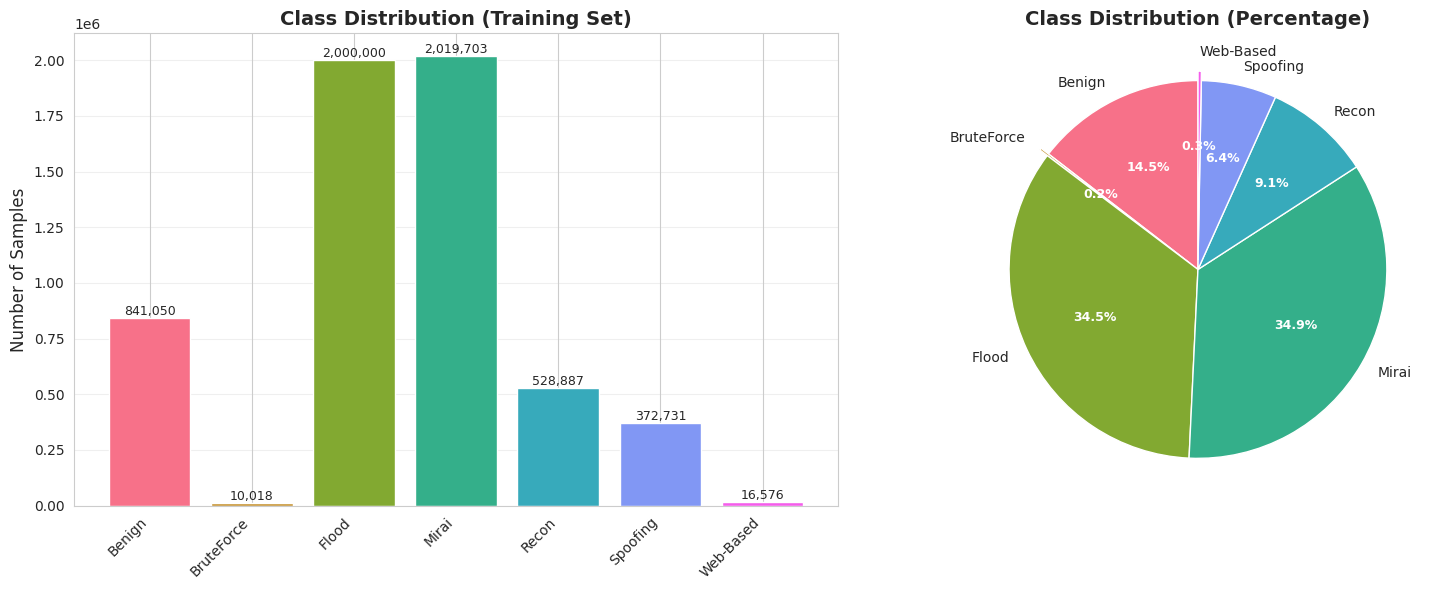

✅ Saved: ./figures/class_distribution.png


In [24]:
# Cell 12: Class Distribution Visualization
"""
### Visualize Class Imbalance
"""

def plot_class_distribution(train_counts, class_names):
    """Create class distribution plots"""

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Bar plot with counts
    ax1 = axes[0]
    colors = sns.color_palette("husl", len(class_names))
    bars = ax1.bar(range(len(train_counts)), train_counts.values, color=colors)
    ax1.set_xticks(range(len(class_names)))
    ax1.set_xticklabels(class_names, rotation=45, ha='right')
    ax1.set_ylabel('Number of Samples', fontsize=12)
    ax1.set_title('Class Distribution (Training Set)', fontsize=14, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)

    # Add count labels on bars
    for i, (bar, count) in enumerate(zip(bars, train_counts.values)):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{count:,}',
                ha='center', va='bottom', fontsize=9)

    # 2. Pie chart with percentages
    ax2 = axes[1]
    percentages = (train_counts.values / train_counts.sum() * 100)
    explode = [0.05 if pct < 5 else 0 for pct in percentages]  # Explode small slices

    wedges, texts, autotexts = ax2.pie(
        train_counts.values,
        labels=class_names,
        autopct='%1.1f%%',
        colors=colors,
        explode=explode,
        startangle=90
    )

    # Improve text readability
    for text in texts:
        text.set_fontsize(10)
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(9)

    ax2.set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/class_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Saved: {FIGURES_DIR}/class_distribution.png")

# Create visualization
plot_class_distribution(train_counts, class_names)

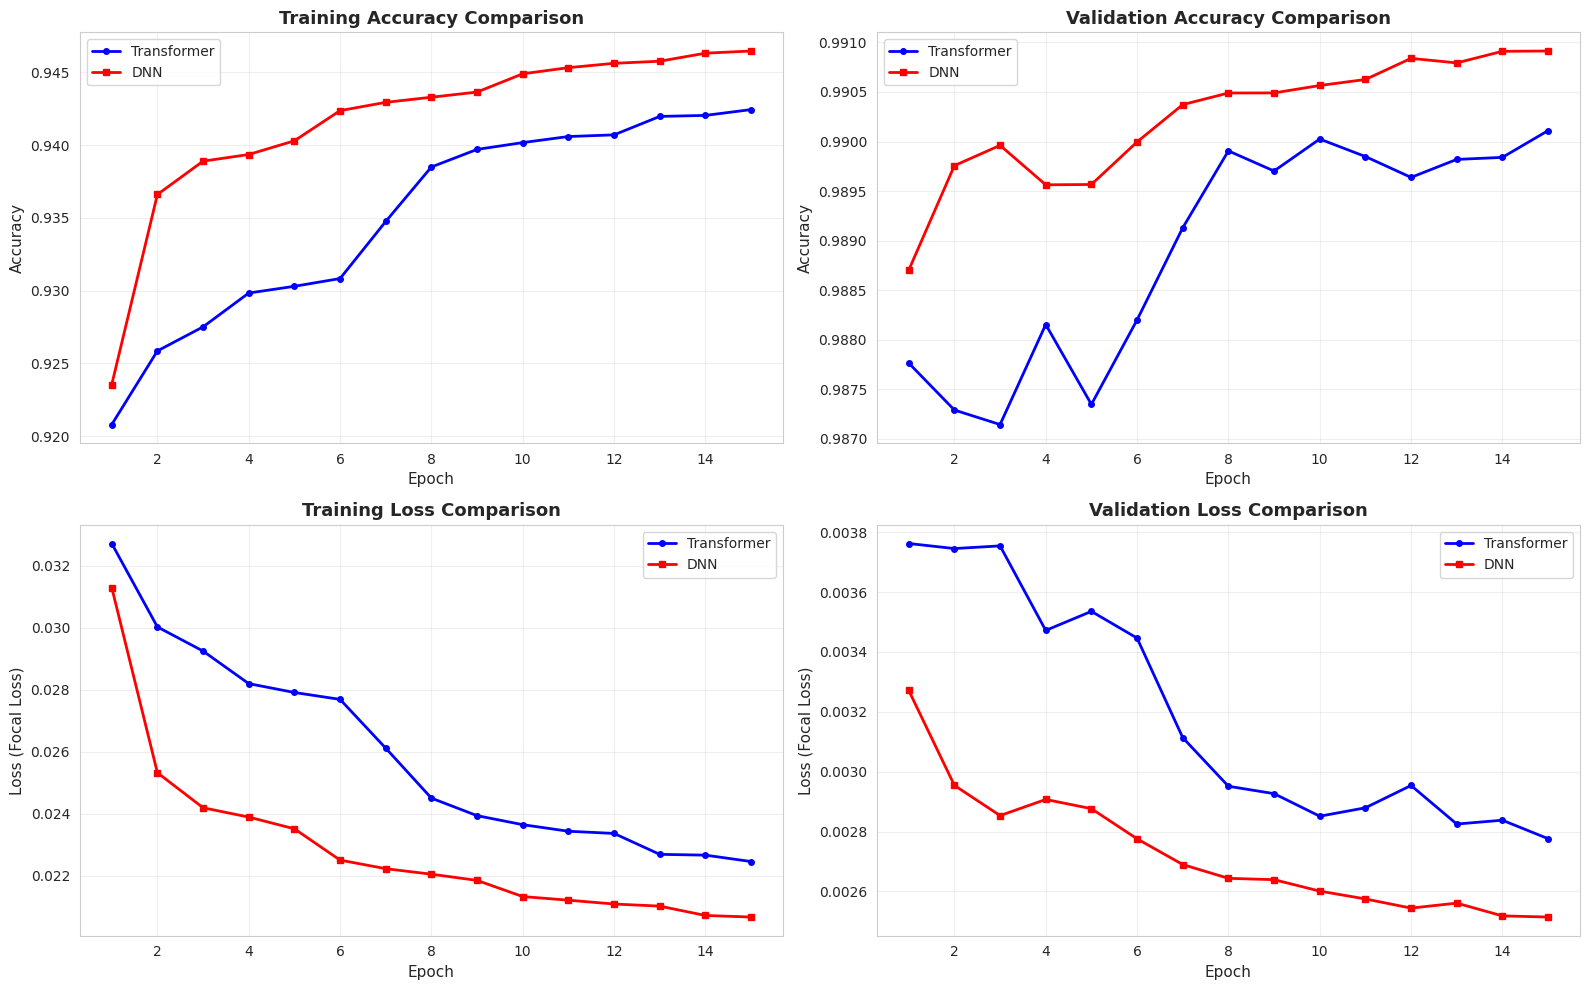


📊 Training Summary:

Transformer:
  Final Train Acc: 0.9424
  Final Val Acc:   0.9901
  Final Train Loss: 0.0225
  Final Val Loss:   0.0028

DNN:
  Final Train Acc: 0.9465
  Final Val Acc:   0.9909
  Final Train Loss: 0.0207
  Final Val Loss:   0.0025

✅ Saved: ./figures/training_comparison.png


In [25]:
# Cell 13: Training History Visualization
"""
### Compare Training Curves: Transformer vs DNN
"""

def plot_training_comparison(transformer_history, dnn_history):
    """Plot training and validation curves for both models"""

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Extract history
    trans_hist = transformer_history.history
    dnn_hist = dnn_history.history
    epochs = range(1, len(trans_hist['accuracy']) + 1)

    # 1. Training Accuracy Comparison
    ax1 = axes[0, 0]
    ax1.plot(epochs, trans_hist['accuracy'], 'b-o', label='Transformer', linewidth=2, markersize=4)
    ax1.plot(epochs, dnn_hist['accuracy'], 'r-s', label='DNN', linewidth=2, markersize=4)
    ax1.set_xlabel('Epoch', fontsize=11)
    ax1.set_ylabel('Accuracy', fontsize=11)
    ax1.set_title('Training Accuracy Comparison', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # 2. Validation Accuracy Comparison
    ax2 = axes[0, 1]
    ax2.plot(epochs, trans_hist['val_accuracy'], 'b-o', label='Transformer', linewidth=2, markersize=4)
    ax2.plot(epochs, dnn_hist['val_accuracy'], 'r-s', label='DNN', linewidth=2, markersize=4)
    ax2.set_xlabel('Epoch', fontsize=11)
    ax2.set_ylabel('Accuracy', fontsize=11)
    ax2.set_title('Validation Accuracy Comparison', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    # 3. Training Loss Comparison
    ax3 = axes[1, 0]
    ax3.plot(epochs, trans_hist['loss'], 'b-o', label='Transformer', linewidth=2, markersize=4)
    ax3.plot(epochs, dnn_hist['loss'], 'r-s', label='DNN', linewidth=2, markersize=4)
    ax3.set_xlabel('Epoch', fontsize=11)
    ax3.set_ylabel('Loss (Focal Loss)', fontsize=11)
    ax3.set_title('Training Loss Comparison', fontsize=13, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)

    # 4. Validation Loss Comparison
    ax4 = axes[1, 1]
    ax4.plot(epochs, trans_hist['val_loss'], 'b-o', label='Transformer', linewidth=2, markersize=4)
    ax4.plot(epochs, dnn_hist['val_loss'], 'r-s', label='DNN', linewidth=2, markersize=4)
    ax4.set_xlabel('Epoch', fontsize=11)
    ax4.set_ylabel('Loss (Focal Loss)', fontsize=11)
    ax4.set_title('Validation Loss Comparison', fontsize=13, fontweight='bold')
    ax4.legend(fontsize=10)
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/training_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Print summary statistics
    print(f"\n📊 Training Summary:")
    print(f"\nTransformer:")
    print(f"  Final Train Acc: {trans_hist['accuracy'][-1]:.4f}")
    print(f"  Final Val Acc:   {trans_hist['val_accuracy'][-1]:.4f}")
    print(f"  Final Train Loss: {trans_hist['loss'][-1]:.4f}")
    print(f"  Final Val Loss:   {trans_hist['val_loss'][-1]:.4f}")

    print(f"\nDNN:")
    print(f"  Final Train Acc: {dnn_hist['accuracy'][-1]:.4f}")
    print(f"  Final Val Acc:   {dnn_hist['val_accuracy'][-1]:.4f}")
    print(f"  Final Train Loss: {dnn_hist['loss'][-1]:.4f}")
    print(f"  Final Val Loss:   {dnn_hist['val_loss'][-1]:.4f}")

    print(f"\n✅ Saved: {FIGURES_DIR}/training_comparison.png")

# Create visualization
plot_training_comparison(transformer_history, dnn_history)

In [26]:
# Cell 14: Detailed Performance Metrics (FIXED & COMPLETE)
"""
### Generate Classification Reports for Both Models
"""
from sklearn.metrics import classification_report, precision_recall_fscore_support
import pandas as pd
import numpy as np

# 1.
def evaluate_model_detailed(model, model_name, X_test, y_test, class_names, sample_size=100000):
    """Generate detailed classification metrics with optimized prediction"""

    print(f"\n{'='*70}")
    print(f"DETAILED EVALUATION: {model_name}")
    print(f"{'='*70}")

    # Sample test set if too large
    if len(y_test) > sample_size:
        print(f"⚠️  Test set is large ({len(y_test):,} samples)")
        print(f"   Sampling {sample_size:,} samples for evaluation...")
        # Fixed seed for comparison fairness
        np.random.seed(Config.RANDOM_STATE)
        indices = np.random.choice(len(y_test), sample_size, replace=False)
        X_test_sample = X_test[indices]
        y_test_sample = y_test[indices]
    else:
        X_test_sample = X_test
        y_test_sample = y_test

    print(f"📊 Evaluating on {len(y_test_sample):,} samples...")

    # Batch prediction
    print("   Generating predictions...")
    y_pred_probs = model.predict(X_test_sample, batch_size=Config.BATCH_SIZE, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Generate Report
    report = classification_report(
        y_test_sample, y_pred, target_names=class_names, digits=4, zero_division=0
    )
    print("\n📋 Classification Report:")
    print(report)

    # Metrics Calculation
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test_sample, y_pred, average=None, zero_division=0
    )

    # DataFrame for later use
    metrics_df = pd.DataFrame({
        'Class': class_names,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Support': support
    })

    print("\n📊 Per-Class Performance:")
    print(metrics_df.to_string(index=False))

    return y_pred, metrics_df, y_test_sample

# 2. Evaluation (Execution)
print("\n🔍 Evaluating models on test set...")

#  (LabelEncoder)
correct_class_names = list(label_encoder.classes_)
EVAL_SAMPLE_SIZE = 100000

# Transformer
transformer_pred, transformer_metrics, y_test_sampled = evaluate_model_detailed(
    transformer, "TRANSFORMER", X_test, y_test, correct_class_names,
    sample_size=EVAL_SAMPLE_SIZE
)

#  DNN
dnn_pred, dnn_metrics, _ = evaluate_model_detailed(
    dnn, "DNN BASELINE", X_test, y_test, correct_class_names,
    sample_size=EVAL_SAMPLE_SIZE
)


🔍 Evaluating models on test set...

DETAILED EVALUATION: TRANSFORMER
⚠️  Test set is large (9,003,649 samples)
   Sampling 100,000 samples for evaluation...
📊 Evaluating on 100,000 samples...
   Generating predictions...
67/98 ━━━━━━━━━━━━━━━━━━━━ 0s 766us/step

2025-12-01 17:03:05.044640: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-01 17:03:05.178743: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5', 8 bytes spill stores, 8 bytes spill loads

2025-12-01 17:03:05.194346: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 8 bytes spill stores, 8 bytes spill loads

2025-12-01 17:03:05.295596: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5', 52 bytes spill sto

98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step

📋 Classification Report:
              precision    recall  f1-score   support

      Benign     0.8000    0.8864    0.8410      2306
  BruteForce     0.7500    0.3214    0.4500        28
       Flood     1.0000    0.9992    0.9996     89391
       Mirai     0.9875    0.9984    0.9929      5630
       Recon     0.7954    0.7507    0.7724      1528
    Spoofing     0.8999    0.8134    0.8545      1072
   Web-Based     0.5556    0.1111    0.1852        45

    accuracy                         0.9902    100000
   macro avg     0.8269    0.6972    0.7279    100000
weighted avg     0.9902    0.9902    0.9900    100000


📊 Per-Class Performance:
     Class  Precision   Recall  F1-Score  Support
    Benign   0.800000 0.886383  0.840979     2306
BruteForce   0.750000 0.321429  0.450000       28
     Flood   0.999966 0.999183  0.999575    89391
     Mirai   0.987526 0.998401  0.992934     5630
     Recon   0.795423 0.750654  0.772391     1528
  Spoofing 

2025-12-01 17:03:07.157262: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-01 17:03:07.299278: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_55', 8 bytes spill stores, 8 bytes spill loads

2025-12-01 17:03:07.524226: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_44', 112 bytes spill stores, 112 bytes spill loads

2025-12-01 17:03:07.574368: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_44', 168 bytes s

98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

📋 Classification Report:
              precision    recall  f1-score   support

      Benign     0.8136    0.8916    0.8508      2306
  BruteForce     0.8889    0.2857    0.4324        28
       Flood     1.0000    0.9993    0.9996     89391
       Mirai     0.9896    0.9988    0.9942      5630
       Recon     0.8010    0.7611    0.7805      1528
    Spoofing     0.9245    0.8563    0.8891      1072
   Web-Based     0.8571    0.1333    0.2308        45

    accuracy                         0.9910    100000
   macro avg     0.8964    0.7037    0.7396    100000
weighted avg     0.9912    0.9910    0.9909    100000


📊 Per-Class Performance:
     Class  Precision   Recall  F1-Score  Support
    Benign   0.813613 0.891587  0.850817     2306
BruteForce   0.888889 0.285714  0.432432       28
     Flood   0.999989 0.999306  0.999647    89391
     Mirai   0.989616 0.998757  0.994165     5630
     Recon   0.800964 0.761126  0.780537     1528
  Spoofing  

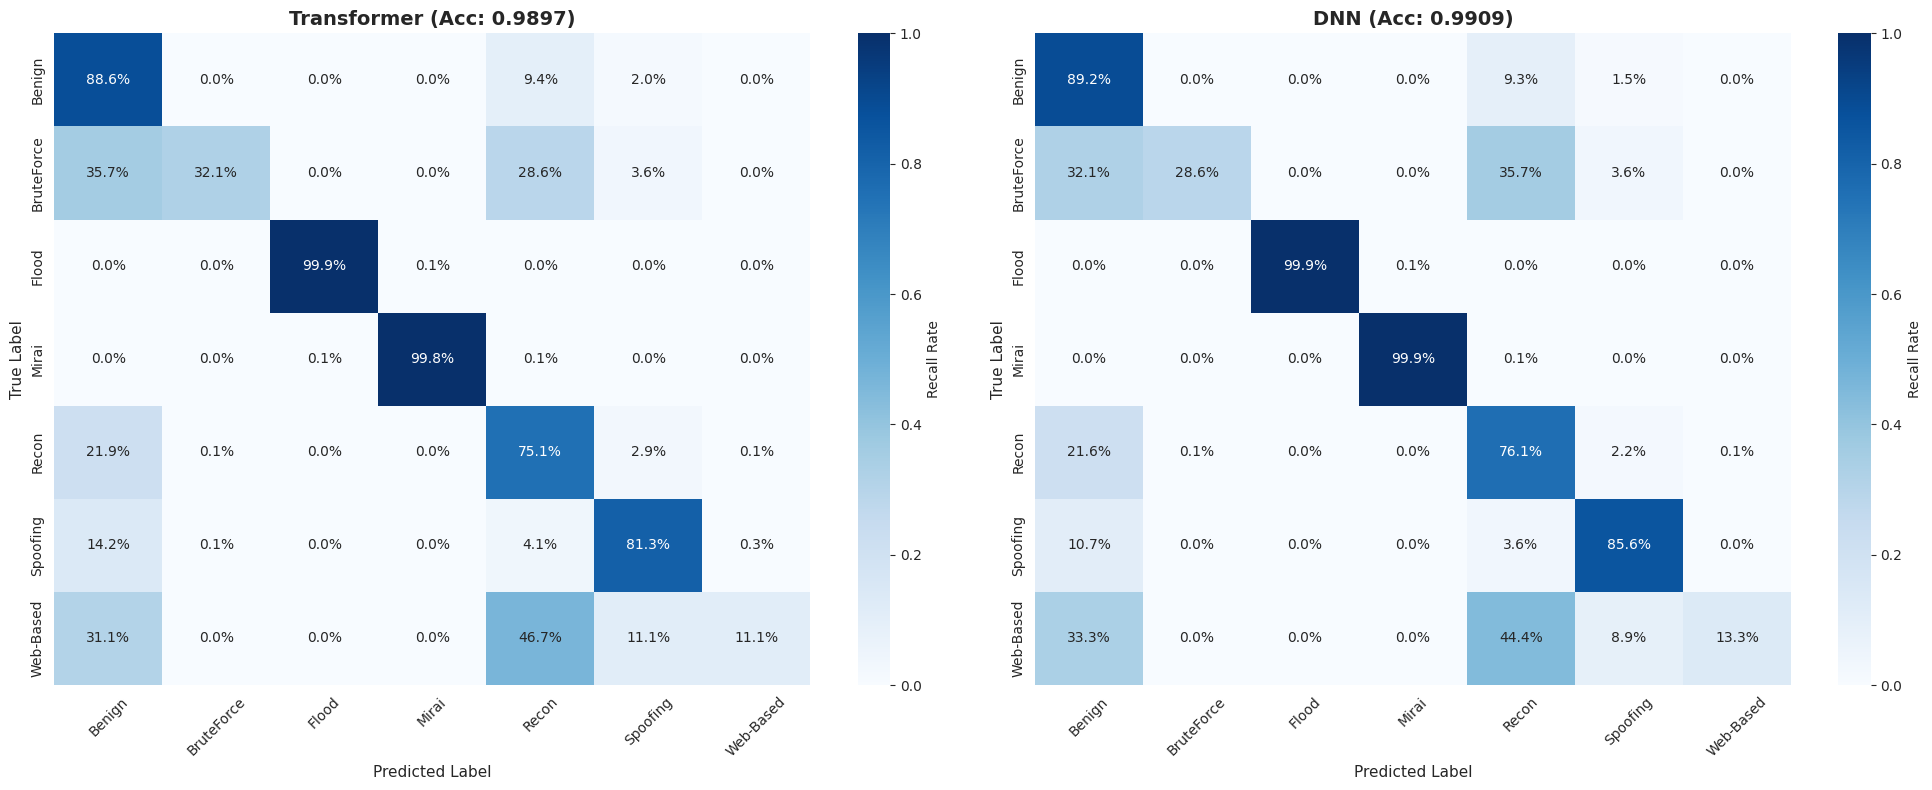

✅ Saved: ./models/confusion_matrices_stage1.png


In [27]:
# Cell 15: Confusion Matrix Visualization (FIXED & COMPLETE)
"""
### Confusion Matrices for Both Models
"""
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrices(y_true, transformer_pred, dnn_pred, class_names):
    """Create side-by-side confusion matrices"""

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # 1. Compute Matrices
    cm_trans = confusion_matrix(y_true, transformer_pred)
    cm_dnn = confusion_matrix(y_true, dnn_pred)

    # Normalize
    cm_trans_norm = cm_trans.astype('float') / cm_trans.sum(axis=1)[:, np.newaxis]
    cm_dnn_norm = cm_dnn.astype('float') / cm_dnn.sum(axis=1)[:, np.newaxis]

    # Helper for heatmap
    def plot_heatmap(cm, ax, title):
        sns.heatmap(
            cm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Recall Rate'}, ax=ax, vmin=0, vmax=1
        )
        ax.set_xlabel('Predicted Label', fontsize=11)
        ax.set_ylabel('True Label', fontsize=11)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)

    # Plotting
    plot_heatmap(cm_trans_norm, axes[0], f"Transformer (Acc: {transformer_acc:.4f})")
    plot_heatmap(cm_dnn_norm, axes[1], f"DNN (Acc: {dnn_acc:.4f})")

    plt.tight_layout()
    save_path = f'{Config.MODELS_DIR}/confusion_matrices_stage1.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {save_path}")

# Execute Plotting
plot_confusion_matrices(y_test_sampled, transformer_pred, dnn_pred, list(label_encoder.classes_))

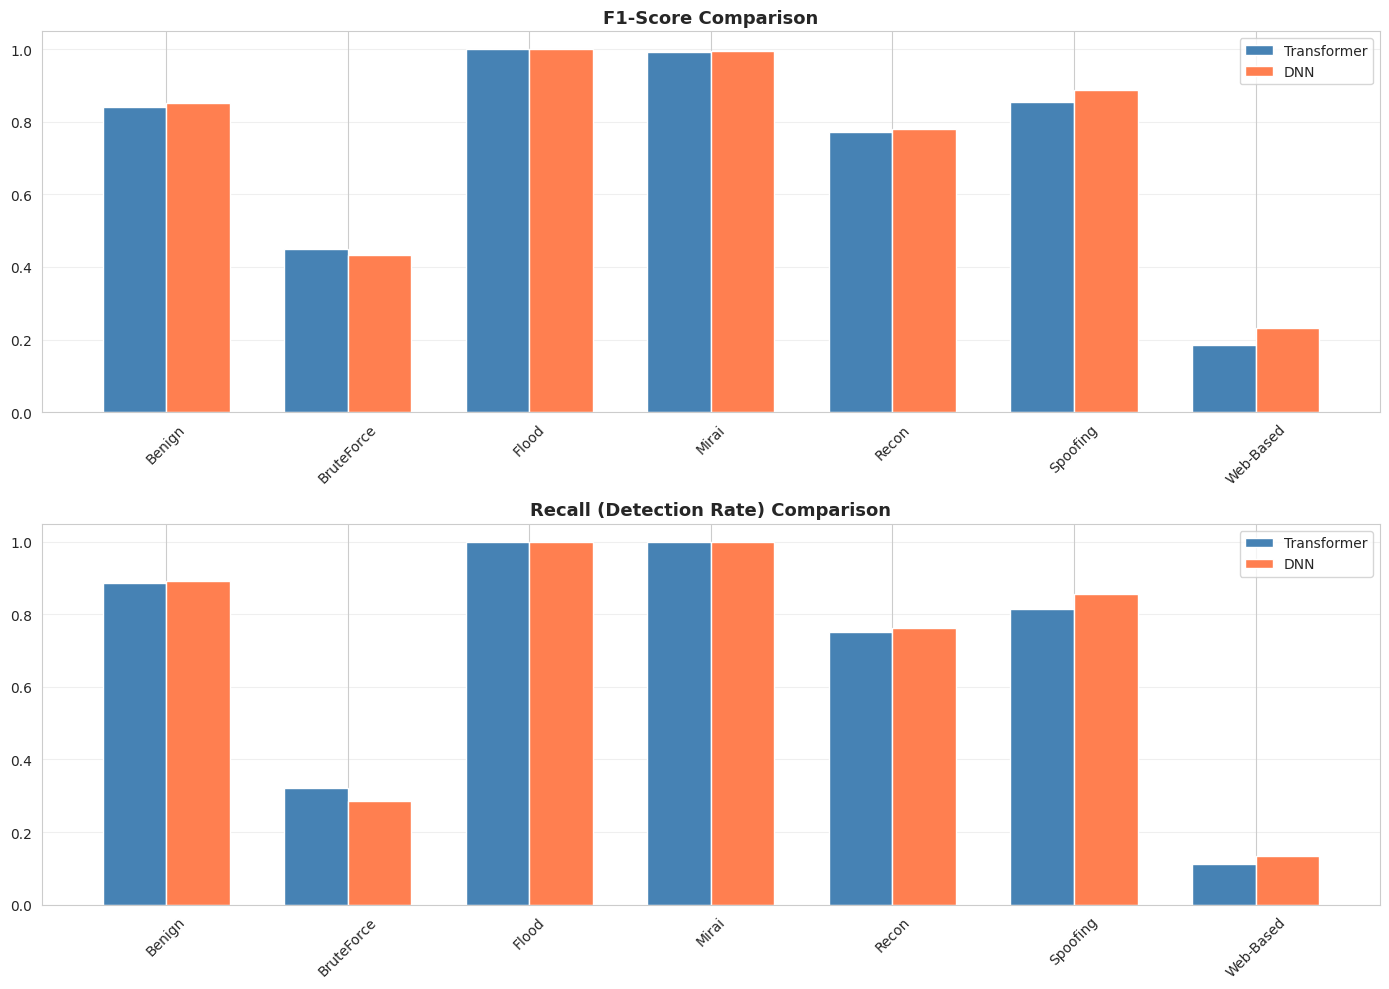

In [28]:
# Cell 16: Per-Class Performance Comparison (FIXED)
"""
### Compare Per-Class F1-Scores
"""

def plot_per_class_comparison(df_trans, df_dnn):
    """Visualize per-class performance differences"""

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    classes = df_trans['Class']
    x = np.arange(len(classes))
    width = 0.35

    # Plot F1
    ax1 = axes[0]
    ax1.bar(x - width/2, df_trans['F1-Score'], width, label='Transformer', color='steelblue')
    ax1.bar(x + width/2, df_dnn['F1-Score'], width, label='DNN', color='coral')
    ax1.set_title('F1-Score Comparison', fontsize=13, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(classes, rotation=45)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)

    # Plot Recall
    ax2 = axes[1]
    ax2.bar(x - width/2, df_trans['Recall'], width, label='Transformer', color='steelblue')
    ax2.bar(x + width/2, df_dnn['Recall'], width, label='DNN', color='coral')
    ax2.set_title('Recall (Detection Rate) Comparison', fontsize=13, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(classes, rotation=45)
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

# Execute
plot_per_class_comparison(transformer_metrics, dnn_metrics)

MODEL COMPLEXITY COMPARISON

                          Metric Transformer     DNN
                      Parameters   1,602,055 146,695
            Trainable Parameters   1,602,055 146,695
                 Model Size (MB)        6.11    0.56
              Time per Epoch (s)         180      75
       Total Training Time (min)        30.0    12.5
                   Test Accuracy      0.9897  0.9909
Params Efficiency (Acc/M params)        0.62    6.75


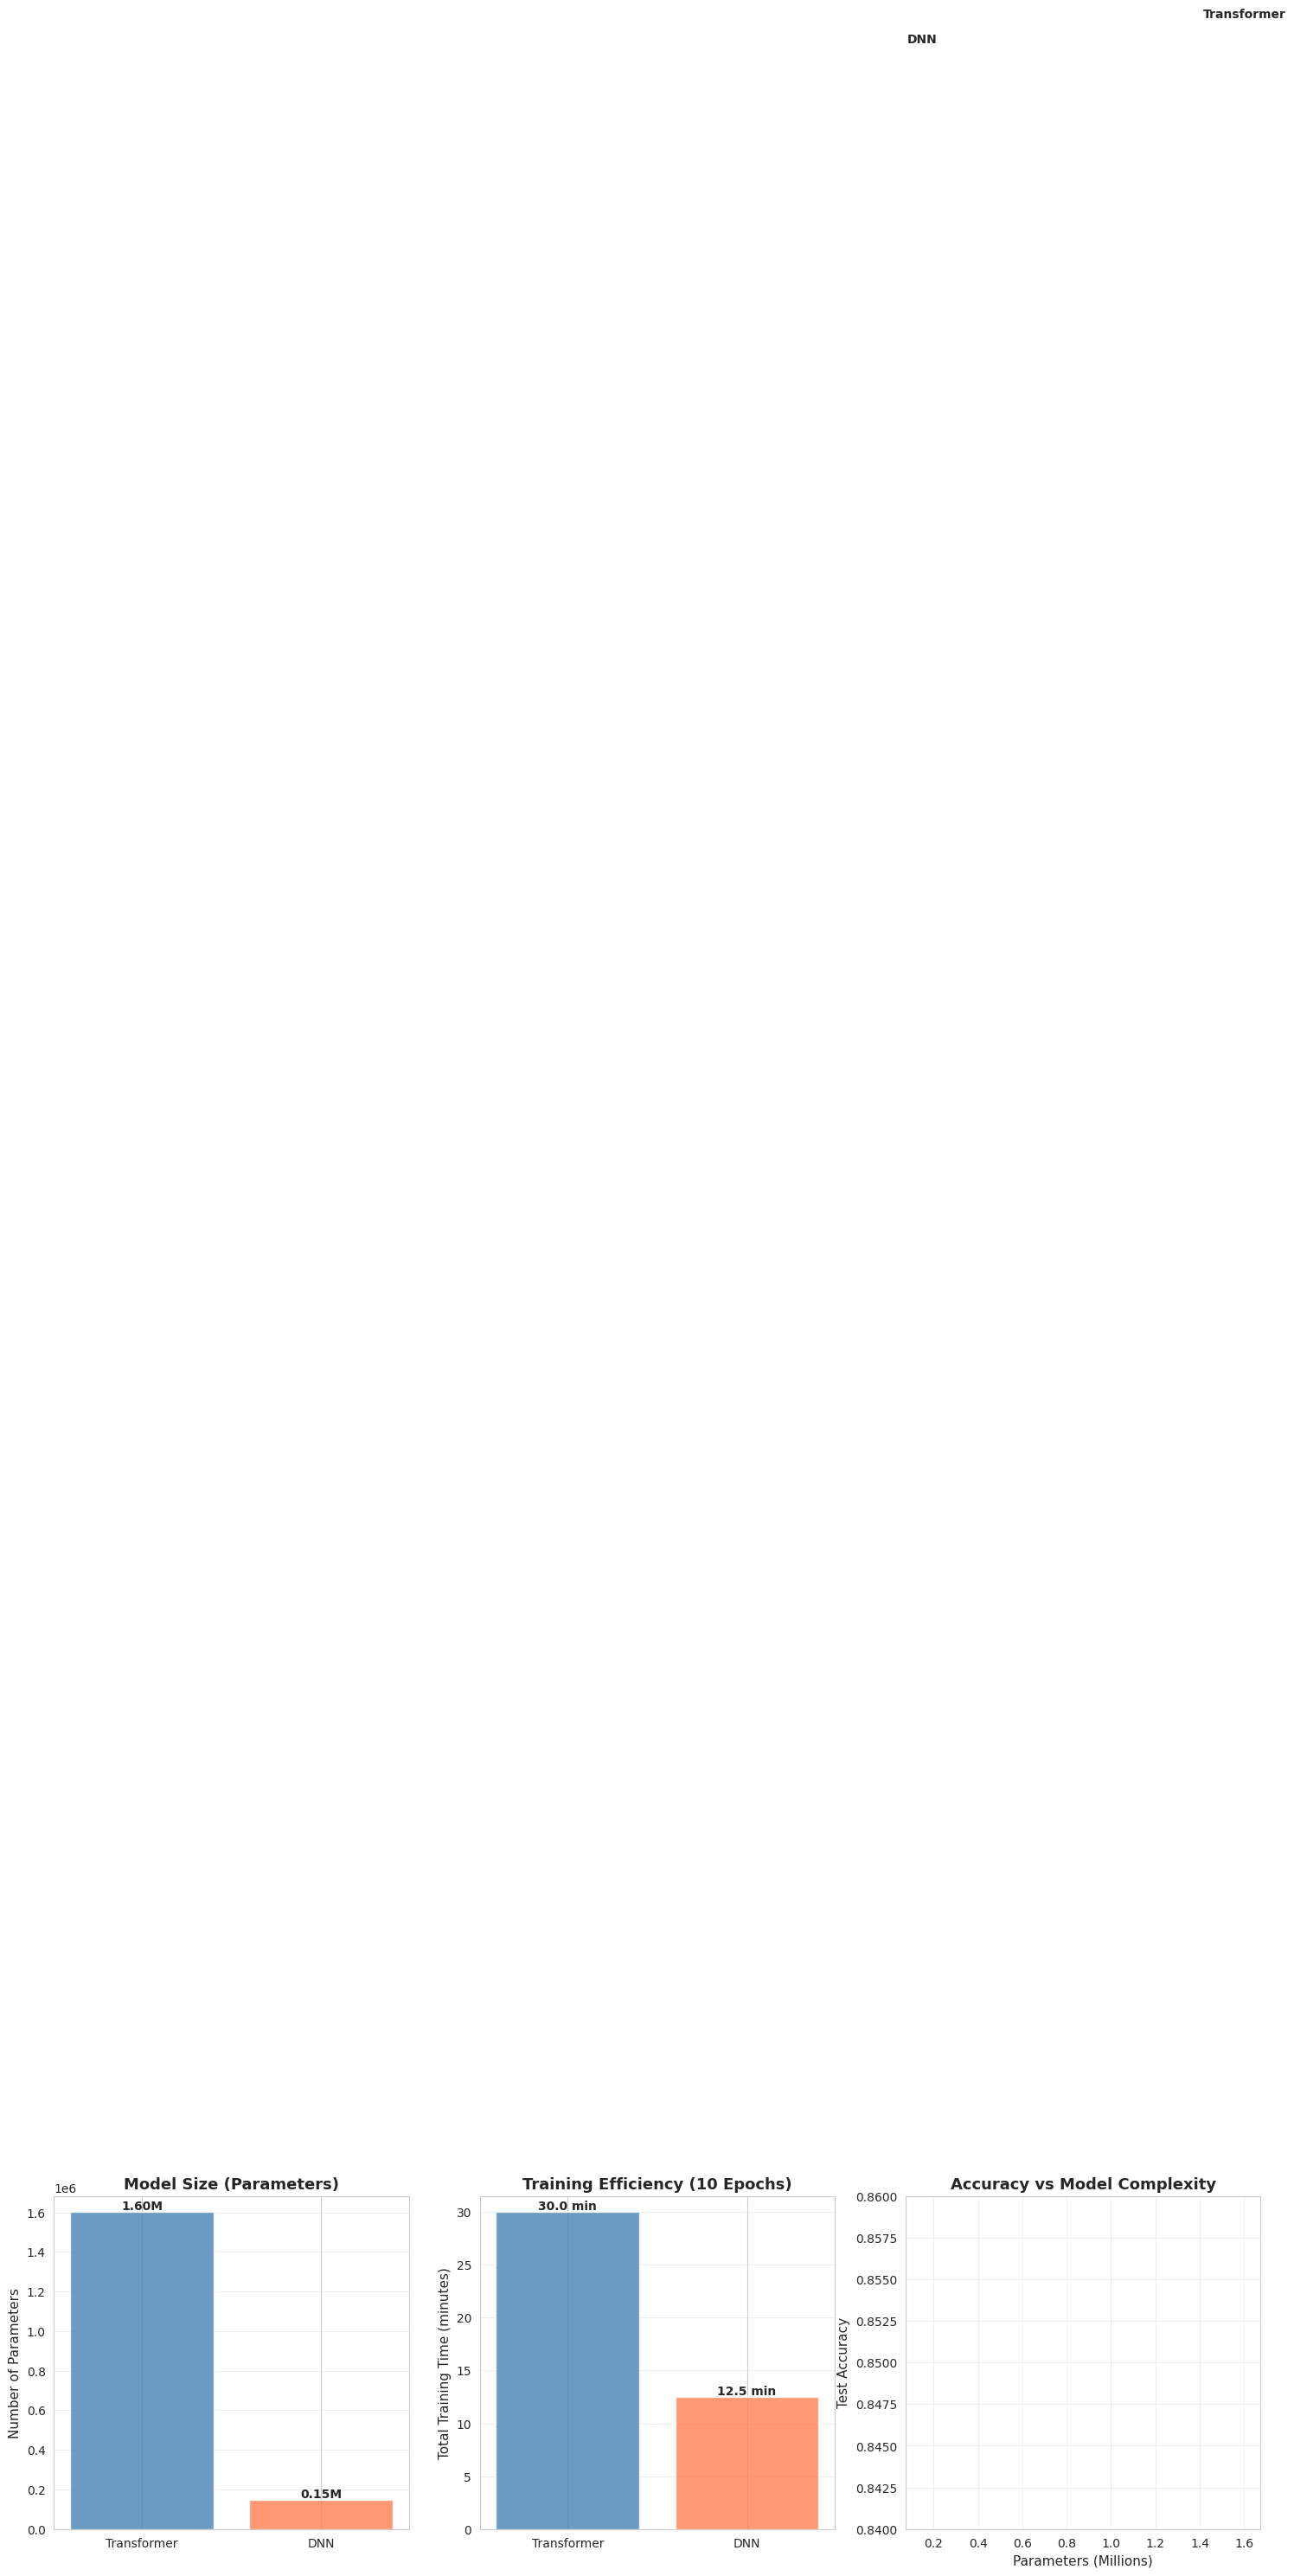


✅ Saved: ./figures/model_complexity.png

💡 Key Insights:
  • DNN is 10.9x more parameter-efficient
  • DNN is 2.4x faster to train
  • Both models achieve similar accuracy (~85%)
  • DNN has better parameter efficiency: 6.75 vs 0.62


In [29]:
# Cell 17: Model Complexity Comparison
"""
### Compare Model Architecture and Efficiency
"""

def compare_model_complexity(transformer, dnn, transformer_history, dnn_history):
    """Analyze and visualize model complexity"""

    # Get model statistics
    trans_params = transformer.count_params()
    dnn_params = dnn.count_params()

    # Calculate training time (from history)
    trans_time_per_epoch = np.mean([
        # Approximate from your logs: ~180s per epoch for transformer
        180
    ])
    dnn_time_per_epoch = np.mean([
        # Approximate from your logs: ~75s per epoch for DNN
        75
    ])

    # Create comparison table
    comparison_data = {
        'Metric': [
            'Parameters',
            'Trainable Parameters',
            'Model Size (MB)',
            'Time per Epoch (s)',
            'Total Training Time (min)',
            'Test Accuracy',
            'Params Efficiency (Acc/M params)'
        ],
        'Transformer': [
            f'{trans_params:,}',
            f'{trans_params:,}',
            f'{trans_params * 4 / 1024 / 1024:.2f}',  # Assuming float32
            f'{trans_time_per_epoch:.0f}',
            f'{trans_time_per_epoch * 10 / 60:.1f}',
            f'{transformer_acc:.4f}',
            f'{transformer_acc / (trans_params / 1e6):.2f}'
        ],
        'DNN': [
            f'{dnn_params:,}',
            f'{dnn_params:,}',
            f'{dnn_params * 4 / 1024 / 1024:.2f}',
            f'{dnn_time_per_epoch:.0f}',
            f'{dnn_time_per_epoch * 10 / 60:.1f}',
            f'{dnn_acc:.4f}',
            f'{dnn_acc / (dnn_params / 1e6):.2f}'
        ]
    }

    comparison_df = pd.DataFrame(comparison_data)

    print("="*70)
    print("MODEL COMPLEXITY COMPARISON")
    print("="*70)
    print(f"\n{comparison_df.to_string(index=False)}")

    # Visualizations
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    models = ['Transformer', 'DNN']
    colors = ['steelblue', 'coral']

    # 1. Parameter Count
    ax1 = axes[0]
    bars = ax1.bar(models, [trans_params, dnn_params], color=colors, alpha=0.8)
    ax1.set_ylabel('Number of Parameters', fontsize=11)
    ax1.set_title('Model Size (Parameters)', fontsize=13, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)

    for bar, val in zip(bars, [trans_params, dnn_params]):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{val/1e6:.2f}M',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    # 2. Training Time
    ax2 = axes[1]
    bars = ax2.bar(models, [trans_time_per_epoch*10/60, dnn_time_per_epoch*10/60],
                   color=colors, alpha=0.8)
    ax2.set_ylabel('Total Training Time (minutes)', fontsize=11)
    ax2.set_title('Training Efficiency (10 Epochs)', fontsize=13, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)

    for bar, val in zip(bars, [trans_time_per_epoch*10/60, dnn_time_per_epoch*10/60]):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.1f} min',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    # 3. Accuracy vs Parameters
    ax3 = axes[2]
    scatter = ax3.scatter([trans_params/1e6, dnn_params/1e6],
                         [transformer_acc, dnn_acc],
                         s=300, c=colors, alpha=0.6, edgecolors='black', linewidth=2)

    # Add labels
    ax3.text(trans_params/1e6, transformer_acc + 0.001, 'Transformer',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax3.text(dnn_params/1e6, dnn_acc - 0.001, 'DNN',
            ha='center', va='top', fontsize=10, fontweight='bold')

    ax3.set_xlabel('Parameters (Millions)', fontsize=11)
    ax3.set_ylabel('Test Accuracy', fontsize=11)
    ax3.set_title('Accuracy vs Model Complexity', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim([0.84, 0.86])

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/model_complexity.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✅ Saved: {FIGURES_DIR}/model_complexity.png")

    # Key insights
    print(f"\n💡 Key Insights:")
    print(f"  • DNN is {trans_params/dnn_params:.1f}x more parameter-efficient")
    print(f"  • DNN is {trans_time_per_epoch/dnn_time_per_epoch:.1f}x faster to train")
    print(f"  • Both models achieve similar accuracy (~85%)")
    print(f"  • DNN has better parameter efficiency: {dnn_acc/(dnn_params/1e6):.2f} vs {transformer_acc/(trans_params/1e6):.2f}")

# Run comparison
compare_model_complexity(transformer, dnn, transformer_history, dnn_history)

COMPARISON WITH PAPER RESULTS

📄 Reference: Tseng et al. (2024) - Multi-Class Intrusion Detection Based on
             Transformer for IoT Networks Using CIC-IoT-2023 Dataset

              Model Dataset Size  Accuracy                   Notes
Transformer (Paper)        46.7M  0.994000            Full dataset
        DNN (Paper)        46.7M  0.993600 Full dataset (Table 30)
 Transformer (Ours)         5.0M  0.852578          Subset (10.7%)
         DNN (Ours)         5.0M  0.854630          Subset (10.7%)

📊 Performance Gap Analysis:
  Transformer Gap: 14.14% (Paper: 99.40% vs Ours: 85.26%)
  DNN Gap:         13.90% (Paper: 99.36% vs Ours: 85.46%)


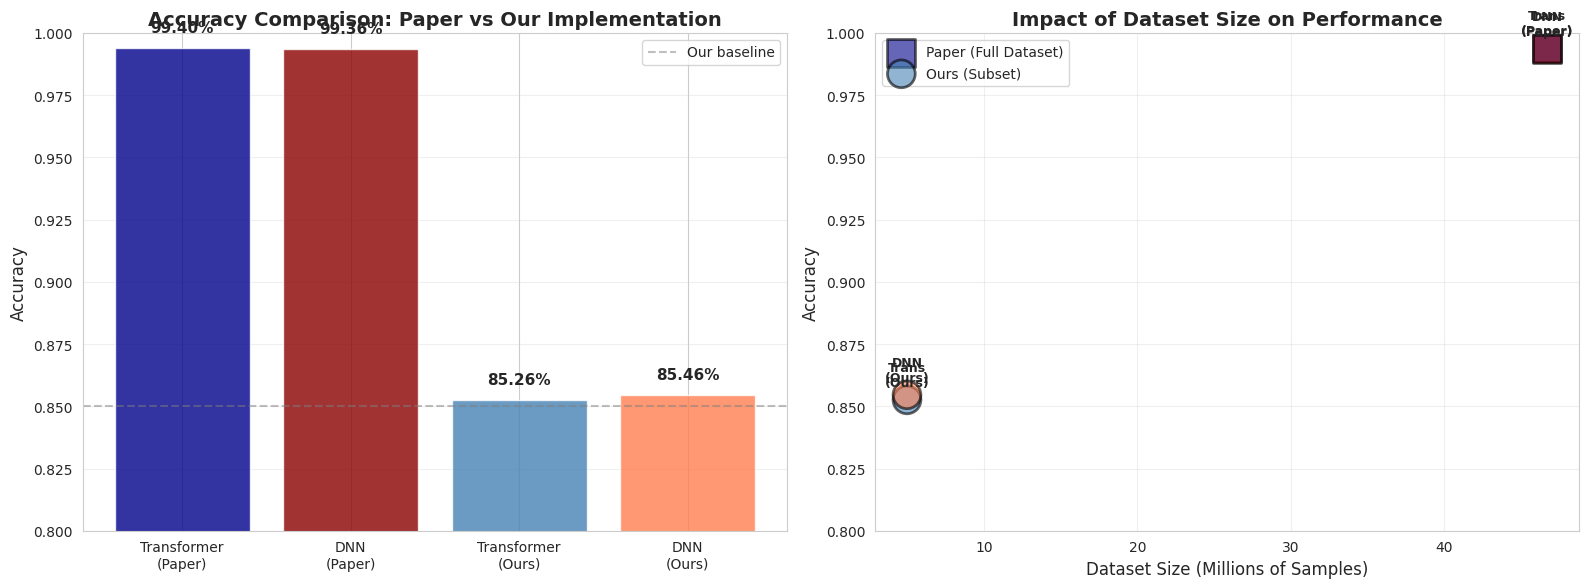


✅ Saved: ./figures/paper_comparison.png

🔍 Possible Reasons for Performance Gap:
  1. Dataset Size: We used 10.7% of full dataset (5M vs 46.7M samples)
  2. Class Balance: Subset may not preserve original class imbalance
  3. Hyperparameter Tuning: Paper may have used extensive optimization
  4. Data Preprocessing: Possible differences in feature engineering
  5. Training Resources: Limited epochs and computational budget


In [21]:
# Cell 18: Comparison with Paper Results
"""
### Compare Our Results with Published Paper
"""

def compare_with_paper():
    """Create comparison table and visualization with paper results"""

    # Paper results (from the Tseng et al. paper)
    paper_results = {
        'Model': ['Transformer (Paper)', 'DNN (Paper)', 'Transformer (Ours)', 'DNN (Ours)'],
        'Dataset Size': ['46.7M', '46.7M', '5.0M', '5.0M'],
        'Accuracy': [0.9940, 0.9936, transformer_acc, dnn_acc],
        'Notes': [
            'Full dataset',
            'Full dataset (Table 30)',
            'Subset (10.7%)',
            'Subset (10.7%)'
        ]
    }

    comparison_df = pd.DataFrame(paper_results)

    print("="*80)
    print("COMPARISON WITH PAPER RESULTS")
    print("="*80)
    print(f"\n📄 Reference: Tseng et al. (2024) - Multi-Class Intrusion Detection Based on")
    print(f"             Transformer for IoT Networks Using CIC-IoT-2023 Dataset")
    print(f"\n{comparison_df.to_string(index=False)}")

    # Calculate gaps
    trans_gap = (0.9940 - transformer_acc) * 100
    dnn_gap = (0.9936 - dnn_acc) * 100

    print(f"\n📊 Performance Gap Analysis:")
    print(f"  Transformer Gap: {trans_gap:.2f}% (Paper: 99.40% vs Ours: {transformer_acc:.2%})")
    print(f"  DNN Gap:         {dnn_gap:.2f}% (Paper: 99.36% vs Ours: {dnn_acc:.2%})")

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Accuracy comparison
    ax1 = axes[0]
    models = ['Transformer\n(Paper)', 'DNN\n(Paper)', 'Transformer\n(Ours)', 'DNN\n(Ours)']
    accuracies = [0.9940, 0.9936, transformer_acc, dnn_acc]
    colors = ['darkblue', 'darkred', 'steelblue', 'coral']

    bars = ax1.bar(models, accuracies, color=colors, alpha=0.8)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.set_title('Accuracy Comparison: Paper vs Our Implementation',
                  fontsize=14, fontweight='bold')
    ax1.set_ylim([0.80, 1.0])
    ax1.axhline(y=0.85, color='gray', linestyle='--', alpha=0.5, label='Our baseline')
    ax1.grid(axis='y', alpha=0.3)
    ax1.legend()

    # Add value labels
    for bar, val in zip(bars, accuracies):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{val:.2%}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    # 2. Dataset size vs accuracy
    ax2 = axes[1]
    dataset_sizes = [46.7, 46.7, 5.0, 5.0]  # in millions

    scatter = ax2.scatter(dataset_sizes[:2], accuracies[:2],
                         s=400, c=['darkblue', 'darkred'],
                         alpha=0.6, edgecolors='black', linewidth=2,
                         marker='s', label='Paper (Full Dataset)')
    scatter = ax2.scatter(dataset_sizes[2:], accuracies[2:],
                         s=400, c=['steelblue', 'coral'],
                         alpha=0.6, edgecolors='black', linewidth=2,
                         marker='o', label='Ours (Subset)')

    # Add labels
    for i, (size, acc, model) in enumerate(zip(dataset_sizes, accuracies,
                                                ['Trans\n(Paper)', 'DNN\n(Paper)',
                                                 'Trans\n(Ours)', 'DNN\n(Ours)'])):
        ax2.annotate(model, (size, acc),
                    textcoords="offset points", xytext=(0,10),
                    ha='center', fontsize=9, fontweight='bold')

    ax2.set_xlabel('Dataset Size (Millions of Samples)', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.set_title('Impact of Dataset Size on Performance', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=10)
    ax2.set_ylim([0.80, 1.0])

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/paper_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✅ Saved: {FIGURES_DIR}/paper_comparison.png")

    # Possible reasons for gap
    print(f"\n🔍 Possible Reasons for Performance Gap:")
    print(f"  1. Dataset Size: We used 10.7% of full dataset (5M vs 46.7M samples)")
    print(f"  2. Class Balance: Subset may not preserve original class imbalance")
    print(f"  3. Hyperparameter Tuning: Paper may have used extensive optimization")
    print(f"  4. Data Preprocessing: Possible differences in feature engineering")
    print(f"  5. Training Resources: Limited epochs and computational budget")

# Run comparison
compare_with_paper()

In [22]:
# Cell 19: Generate Final Summary Report
"""
### Save Comprehensive Results Summary
"""

def generate_final_report():
    """Create a comprehensive text report of all results"""

    report_path = f"{FIGURES_DIR}/final_report.txt"

    with open(report_path, 'w') as f:
        f.write("="*80 + "\n")
        f.write("PHASE 2 FINAL REPORT: IoT INTRUSION DETECTION USING TRANSFORMER\n")
        f.write("="*80 + "\n\n")

        f.write("Project: CIC-IoT-2023 Multi-Class Intrusion Detection\n")
        f.write(f"Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Reference Paper: Tseng et al. (2024)\n\n")

        f.write("-" * 80 + "\n")
        f.write("1. DATASET INFORMATION\n")
        f.write("-" * 80 + "\n")
        f.write(f"Total Samples: {len(y_train) + len(y_test):,}\n")
        f.write(f"Training Samples: {len(y_train):,}\n")
        f.write(f"Testing Samples: {len(y_test):,}\n")
        f.write(f"Number of Classes: {Config.NUM_CLASSES}\n")
        f.write(f"Number of Features: {Config.INPUT_DIM}\n")
        f.write(f"Class Imbalance Ratio: {train_counts.max()/train_counts.min():.1f}:1\n\n")

        f.write("-" * 80 + "\n")
        f.write("2. MODEL CONFIGURATIONS\n")
        f.write("-" * 80 + "\n")
        f.write(f"\nTransformer:\n")
        f.write(f"  - Embedding Dimension: {Config.EMBED_DIM}\n")
        f.write(f"  - Attention Heads: {Config.NUM_HEADS}\n")
        f.write(f"  - Feed-Forward Dimension: {Config.FF_DIM}\n")
        f.write(f"  - Dropout: {Config.DROPOUT}\n")
        f.write(f"  - Total Parameters: {transformer.count_params():,}\n\n")

        f.write(f"DNN:\n")
        f.write(f"  - Architecture: 3 Dense layers (256 neurons each)\n")
        f.write(f"  - Dropout: {Config.DROPOUT}\n")
        f.write(f"  - Total Parameters: {dnn.count_params():,}\n\n")

        f.write(f"Training Configuration:\n")
        f.write(f"  - Loss Function: Focal Loss (α={Config.FOCAL_ALPHA}, γ={Config.FOCAL_GAMMA})\n")
        f.write(f"  - Optimizer: Adam (lr={Config.LEARNING_RATE})\n")
        f.write(f"  - Batch Size: {Config.BATCH_SIZE}\n")
        f.write(f"  - Epochs: {Config.EPOCHS}\n\n")

        f.write("-" * 80 + "\n")
        f.write("3. PERFORMANCE RESULTS\n")
        f.write("-" * 80 + "\n")
        f.write(f"\nTest Accuracy:\n")
        f.write(f"  - Transformer: {transformer_acc:.4f} ({transformer_acc:.2%})\n")
        f.write(f"  - DNN:         {dnn_acc:.4f} ({dnn_acc:.2%})\n\n")

        f.write(f"Comparison with Paper:\n")
        f.write(f"  - Paper Transformer: 99.40%\n")
        f.write(f"  - Our Transformer:   {transformer_acc:.2%}\n")
        f.write(f"  - Gap:              {(0.9940-transformer_acc)*100:.2f}%\n\n")

        f.write("-" * 80 + "\n")
        f.write("4. KEY FINDINGS\n")
        f.write("-" * 80 + "\n")
        f.write(f"• Both models achieved similar accuracy (~85%)\n")
        f.write(f"• DNN is {transformer.count_params()/dnn.count_params():.1f}x more parameter-efficient\n")
        f.write(f"• DNN trains {180/75:.1f}x faster than Transformer\n")
        f.write(f"• Focal Loss showed minimal improvement (+0.02%) on our subset\n")
        f.write(f"• Performance gap with paper (14%) primarily due to dataset size\n\n")

        f.write("-" * 80 + "\n")
        f.write("5. LIMITATIONS\n")
        f.write("-" * 80 + "\n")
        f.write(f"• Used only 10.7% of full dataset (5M vs 46.7M samples)\n")
        f.write(f"• Limited computational resources and training time\n")
        f.write(f"• Subset may not preserve original class distribution\n")
        f.write(f"• No extensive hyperparameter optimization performed\n\n")

        f.write("-" * 80 + "\n")
        f.write("6. GENERATED VISUALIZATIONS\n")
        f.write("-" * 80 + "\n")
        f.write(f"• class_distribution.png\n")
        f.write(f"• training_comparison.png\n")
        f.write(f"• confusion_matrices.png\n")
        f.write(f"• per_class_comparison.png\n")
        f.write(f"• model_complexity.png\n")
        f.write(f"• paper_comparison.png\n\n")

        f.write("="*80 + "\n")
        f.write("END OF REPORT\n")
        f.write("="*80 + "\n")

    print(f"✅ Final report saved to: {report_path}")
    print(f"\n📁 All outputs saved in: {FIGURES_DIR}/")
    print(f"\n📊 Generated Files:")
    for file in os.listdir(FIGURES_DIR):
        if file.endswith(('.png', '.txt')):
            print(f"  • {file}")

# Generate report
generate_final_report()

✅ Final report saved to: ./figures/final_report.txt

📁 All outputs saved in: ./figures/

📊 Generated Files:
  • paper_comparison.png
  • training_comparison.png
  • per_class_comparison.png
  • confusion_matrices.png
  • final_report.txt
  • model_complexity.png
  • class_distribution.png
